<a href="https://colab.research.google.com/github/AlonsoVento/Portafolio_MachineLearning_MarioAlonsoVentoAlvarado/blob/master/MarioAlonsoVentoAlvarado_MachineLearning_AprendizajeSupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aprendizaje Supervisado**

*   **Autor:** Mario Alonso Vento Alvarado
*   **Fecha:** Mayo 2026


#Introducción y objetivo del negocio
WestAirlines es una empresa de transporte aéreo que recientemente realizó una alianza con una empresa de telecomunicaciones para la venta de servicios de comunicación. El archivo EastWestAirlenesNN.xlsx contiene la información de clientes a los que se le ofreció el servicio y
los que respondieron de forma favorable.

Se pide: Elaborar un modelo predictivo que cubra las necesidades de la aerolínea, para potenciar la marca y realizar una venta más efectiva del servicio.

**Variables**

| Variable | Data Type | Max Data Length | Raw Data or Telcom Created Field? | Description|
|---|---|---|---|---|
| `ID#` | NUMBER | | Telcom | Unique ID |
| `Topflight` | CHAR | 1 | Raw | Indicates whether flyer has attained elite "Topflight" status, 1 = yes, 0 = no |
| `Balance` | NUMBER | 8 | Raw | Number of miles eligible for award travel |
| `Qual_miles` | NUMBER | 8 | Raw | Number of miles counted as qualifying for Topflight status |
| `cc1_miles?` | CHAR | 1 | Raw | Has member earned miles with airline freq. flyer credit card in the past 12 months (1=Yes/0=No)? |
| `cc2_miles?` | CHAR | 1 | Raw | Has member earned miles with Rewards credit card in the past 12 months (1=Yes/0=No)? |
| `cc3_miles?` | CHAR | 1 | Raw | Has member earned miles with Small Business credit card in the past 12 months (1=Yes/0=No)? |
| `Bonus_miles` | NUMBER | | Raw | Number of miles earned from non-flight bonus transactions in the past 12 months |
| `Bonus_trans` | NUMBER | | Raw | Number of non-flight bonus transactions in the past 12 months |
| `Flight_miles_12mo` | NUMBER | | Raw | Number of flight miles in the past 12 months |
| `Flight_trans_12` | NUMBER | | Raw | Number of flight transactions in the past 12 months |
| `Online_12` | NUMBER | | Raw | Number of online purchases within the past 12 months |
| `Email` | CHAR | 1 | Raw | E-mail address on file. 1= yes, 0 =no? |
| `Club_member` | NUMBER | | Telcom | Member of the airline's club (paid membership), 1=yes, 0=no |
| `Any_cc_miles_12mo` | NUMBER | | Telcom | Dummy variable indicating whether member added miles on any credit card type within the past 12 months (1='Y', 0='N') |
| `Phone_sale` | NUMBER | | Telcom | Dummy variable indicating whether member purchased Telcom service as a result of the direct mail campaign (1=sale, 0=no sale) |

#**1. Análisis Exploratorio de Datos**



##**1.1. Configuración y Análisis Inicial**

###**1.1.1. Importación de Librerías**

In [47]:
import numpy as np # numpy es una librería de python para poder trabajar con operaciones matematicas
import pandas as pd # pandas sirve para poder trabajar con estructuras de datos (columnas (listas, series), dataframe)
import seaborn as sns # seaborn sirve para poder trabajar con graficos
import matplotlib.pyplot as plt # matplotlib sirve para poder trabajar con graficos
import io # es una librería de complemento para poder realizar la carga de datos
from sklearn import preprocessing # librerias de feature engineering
import plotly.express as px # sirve para poder trabajar con graficos de forma mas interactiva

###**1.1.2. Conexión Google Drive**

In [48]:
# Creando conexión con google drive
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [49]:
from google.colab import drive
drive.mount('/content/drive')
#Cargar archivo EastWestAirlinesNN.csv a la carpeta drive que se ha montado

Mounted at /content/drive


###**1.1.3. Importación Data**

In [50]:
data = pd.read_csv('/content/drive/MyDrive/DMC Institute/Especialización Machine Learning/Portafolio_MachineLearning_MarioAlonsoVentoAlvarado/Caso Aplicativo - West Airlines/Data West Airlines/EastWestAirlinesNN.csv',sep = ',')
data.head(8)

,ID#,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
0,1.0,0.0,28143.0,0.0,0.0,1.0,0.0,174.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2.0,0.0,19244.0,0.0,0.0,0.0,0.0,215.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,41354.0,0.0,1.0,0.0,0.0,4123.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,4.0,0.0,14776.0,0.0,0.0,0.0,0.0,500.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,1.0,97752.0,0.0,1.0,0.0,0.0,43300.0,26.0,2077.0,4.0,0.0,1.0,0.0,1.0,0.0
5,6.0,0.0,16420.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
6,7.0,0.0,84914.0,0.0,1.0,0.0,0.0,27482.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
7,8.0,1.0,20856.0,0.0,0.0,0.0,0.0,5250.0,4.0,250.0,1.0,0.0,1.0,0.0,0.0,0.0


###**1.1.4. Limpieza Inicial de Data**

Se verifica en la data que en las últimas dos filas hay conteos que no sirven al análisis; por lo cual procederemos a eliminarlos.

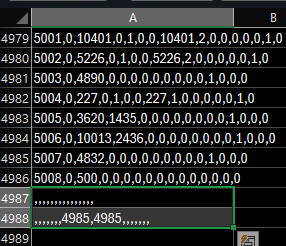

In [51]:
data = data.iloc[:-2] # Elimina las últimas 2 filas
data.info() # Vuelve a verificar la información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4985 entries, 0 to 4984
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID#                4985 non-null   float64
 1   Topflight          4985 non-null   float64
 2   Balance            4985 non-null   float64
 3   Qual_miles         4985 non-null   float64
 4   cc1_miles?         4985 non-null   float64
 5   cc2_miles?         4985 non-null   float64
 6   cc3_miles?         4985 non-null   float64
 7   Bonus_miles        4985 non-null   float64
 8   Bonus_trans        4985 non-null   float64
 9   Flight_miles_12mo  4985 non-null   float64
 10  Flight_trans_12    4985 non-null   float64
 11  Online_12          4985 non-null   float64
 12  Email              4985 non-null   float64
 13  Club_member        4985 non-null   float64
 14  Any_cc_miles_12mo  4985 non-null   float64
 15  Phone_sale         4985 non-null   float64
dtypes: float64(16)
memory us

In [52]:
data.head(8)

,ID#,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
0,1.0,0.0,28143.0,0.0,0.0,1.0,0.0,174.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2.0,0.0,19244.0,0.0,0.0,0.0,0.0,215.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,41354.0,0.0,1.0,0.0,0.0,4123.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,4.0,0.0,14776.0,0.0,0.0,0.0,0.0,500.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,1.0,97752.0,0.0,1.0,0.0,0.0,43300.0,26.0,2077.0,4.0,0.0,1.0,0.0,1.0,0.0
5,6.0,0.0,16420.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
6,7.0,0.0,84914.0,0.0,1.0,0.0,0.0,27482.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
7,8.0,1.0,20856.0,0.0,0.0,0.0,0.0,5250.0,4.0,250.0,1.0,0.0,1.0,0.0,0.0,0.0


In [53]:
data.columns.to_list() # columns funcion que te genera una lista con los nombres de las variables

['ID#',
 'Topflight',
 'Balance',
 'Qual_miles',
 'cc1_miles?',
 'cc2_miles?',
 'cc3_miles?',
 'Bonus_miles',
 'Bonus_trans',
 'Flight_miles_12mo',
 'Flight_trans_12',
 'Online_12',
 'Email',
 'Club_member',
 'Any_cc_miles_12mo',
 'Phone_sale']

In [54]:
data.info() # info es una función para tener un resumen de las caracteristicas de mi base datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4985 entries, 0 to 4984
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID#                4985 non-null   float64
 1   Topflight          4985 non-null   float64
 2   Balance            4985 non-null   float64
 3   Qual_miles         4985 non-null   float64
 4   cc1_miles?         4985 non-null   float64
 5   cc2_miles?         4985 non-null   float64
 6   cc3_miles?         4985 non-null   float64
 7   Bonus_miles        4985 non-null   float64
 8   Bonus_trans        4985 non-null   float64
 9   Flight_miles_12mo  4985 non-null   float64
 10  Flight_trans_12    4985 non-null   float64
 11  Online_12          4985 non-null   float64
 12  Email              4985 non-null   float64
 13  Club_member        4985 non-null   float64
 14  Any_cc_miles_12mo  4985 non-null   float64
 15  Phone_sale         4985 non-null   float64
dtypes: float64(16)
memory us

Podemos ver que las 16 variables son numéricas y no hay variables categóricas; sin embargo, sabemos que `Topflight`, `cc1_miles?`, `cc2_miles?`, `cc3_miles?`, `Email`, `Club_member`, `Any_cc_miles_12mo` y `Phone_sale` son variables binarias, por lo que en realidad son variables categóricas.

In [55]:
#Pondremos el tipo de formato de variable correcto según lo señalado previamente

data['Topflight'] = data['Topflight'].astype('object')
data['cc1_miles?'] = data['cc1_miles?'].astype('object')
data['cc2_miles?'] = data['cc2_miles?'].astype('object')
data['cc3_miles?'] = data['cc3_miles?'].astype('object')
data['Email'] = data['Email'].astype('object')
data['Club_member'] = data['Club_member'].astype('object')
data['Any_cc_miles_12mo'] = data['Any_cc_miles_12mo'].astype('object')
data['Phone_sale'] = data['Phone_sale'].astype('object')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4985 entries, 0 to 4984
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID#                4985 non-null   float64
 1   Topflight          4985 non-null   object 
 2   Balance            4985 non-null   float64
 3   Qual_miles         4985 non-null   float64
 4   cc1_miles?         4985 non-null   object 
 5   cc2_miles?         4985 non-null   object 
 6   cc3_miles?         4985 non-null   object 
 7   Bonus_miles        4985 non-null   float64
 8   Bonus_trans        4985 non-null   float64
 9   Flight_miles_12mo  4985 non-null   float64
 10  Flight_trans_12    4985 non-null   float64
 11  Online_12          4985 non-null   float64
 12  Email              4985 non-null   object 
 13  Club_member        4985 non-null   object 
 14  Any_cc_miles_12mo  4985 non-null   object 
 15  Phone_sale         4985 non-null   object 
dtypes: float64(8), object(8)

###**1.1.5. Análisis de Variables**

In [56]:
data.describe() # genera estadisticas descriptivas rápidas de las variables numéricas

,ID#,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12
count,4985.000000,4.985000e+03,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000
mean,2509.425677,6.382099e+04,134.569107,15579.973721,10.663791,426.472618,1.238716,0.054965
std,1445.421664,9.360653e+04,731.679338,22883.585808,9.505390,1428.041859,3.610721,0.506170
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1259.000000,1.419200e+04,0.000000,1000.000000,3.000000,0.000000,0.000000,0.000000
50%,2511.000000,3.469400e+04,0.000000,5900.000000,10.000000,0.000000,0.000000,0.000000
75%,3761.000000,7.796500e+04,0.000000,21426.000000,16.000000,200.000000,1.000000,0.000000
max,5008.000000,1.704838e+06,11148.000000,263685.000000,88.000000,30817.000000,53.000000,11.000000


De las estadísticas obtenidas (data.describe()), podemos deducir lo siguiente sobre las **variables numéricas**:


*   Presencia de valores atípicos y asimetría (skewness): Muchas variables como `Balance`, `Qual_miles`, `Bonus_miles`, `Bonus_trans`, `Flight_miles_12mo`, `Flight_trans_12` y `Online_12` muestran una gran diferencia entre la media y la mediana, y entre el percentil 75 y el valor máximo. Esto indica una distribución asimétrica hacia la derecha, lo que sugiere la presencia de valores atípicos (clientes con valores mucho más altos que la mayoría).

*   Sparsidad en algunas características: Variables como `Qual_miles`, `Flight_miles_12mo`, `Flight_trans_12` y `Online_12` tienen muchos valores en cero (sus percentiles 25, 50 e incluso 75 son muy bajos o cero). Esto significa que una gran parte de los clientes no acumulan millas de calificación, no realizan vuelos frecuentes o no hacen compras en línea en los últimos 12 meses.

*   `ID#` es un identificador: La variable `ID#` tiene valores únicos y un rango amplio, lo que confirma que es un identificador de cliente y no una característica que deba usarse directamente para el modelado predictivo.

*   Consistencia de los rangos: Los valores mínimos son consistentemente cero para muchas métricas (millas, transacciones), lo cual es lógico.

*   Valores faltantes: El count (conteo de valores no nulos) para la mayoría de las columnas es 4985 o 4986, mientras que el total de entradas es 4987. Esto confirma que hay un pequeño número de valores faltantes en casi todas las columnas, como ya se había observado con data.info().

En resumen, la mayoría de las variables numéricas están muy sesgadas y contienen muchos ceros, lo que indica que se necesitará un preprocesamiento cuidadoso (por ejemplo, transformaciones o técnicas de manejo de valores atípicos) antes de usarlas en un modelo de Machine Learning.

In [57]:
data.describe(include=['O']) # describe(include=["O"]) Object formato de variable categorica en python

,Topflight,cc1_miles?,cc2_miles?,cc3_miles?,Email,Club_member,Any_cc_miles_12mo,Phone_sale
count,4985.0,4985.0,4985.0,4985.0,4985.0,4985.0,4985.0,4985.0
unique,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
top,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
freq,4148.0,2590.0,4778.0,4960.0,3234.0,4528.0,2672.0,3943.0


De las estadísticas obtenidas para analizar las variables categóricas, podemos deducir lo siguiente sobre las **variables categóricas**:

*   **Valores faltantes:** El count para todas las variables categóricas es 4985. Esto indica que después de la limpieza realizada, todas las filas tienen valores en estas columnas, no hay valores nulos en el conjunto de datos actual.

*   **Variables binarias:** El unique (valores únicos) para todas estas variables es 2, lo que confirma que son, de hecho, variables binarias. Esto es coherente con la descripción de las variables y el cambio de tipo de dato que realizaste.

*   **Distribución de categorías:** La fila freq muestra la frecuencia de la categoría más común (top). Esto nos permite entender el balance de las categorías:

    *   `Topflight`: La mayoría de los clientes (4148) no tienen el estatus 'Topflight'.
    *   `cc1_miles?`: Una ligera mayoría (2590) sí ganó millas con la tarjeta de crédito de viajero frecuente.
    *   `cc2_miles?`: La gran mayoría (4778) no ganó millas con la tarjeta de crédito de recompensas.
    *   `cc3_miles?`: Una abrumadora mayoría (4960) no ganó millas con la tarjeta de crédito de pequeñas empresas. Esta variable muestra un desequilibrio muy alto.
    *   `Email`: La mayoría de los clientes (3234) tienen una dirección de correo electrónico registrada.
    *   `Club_member`: La mayoría (4528) no es miembro del club de la aerolínea.
    *   `Any_cc_miles_12mo`: La mayoría (2672) sí agregó millas con algún tipo de tarjeta de crédito en los últimos 12 meses.
    *   `Phone_sale` (variable objetivo): La mayoría de los clientes (3943) no compraron el servicio de telecomunicaciones. Esto indica un desequilibrio significativo en la variable objetivo.

Estas estadísticas confirman la naturaleza binaria de las variables y revelan desequilibrios importantes en las categorías de varias de ellas, especialmente en cc3_miles? y la variable objetivo `Phone_sale`. Este desequilibrio será un factor crítico a considerar durante el preprocesamiento y la construcción del modelo para asegurar que el modelo no se sesgue hacia la clase mayoritaria.

##**1.2. Análisis Univariado**

El análisis univariado nos permite examinar las características individuales de cada variable en el conjunto de datos.

###**1.2.1. Visualización de Variables Numéricas**

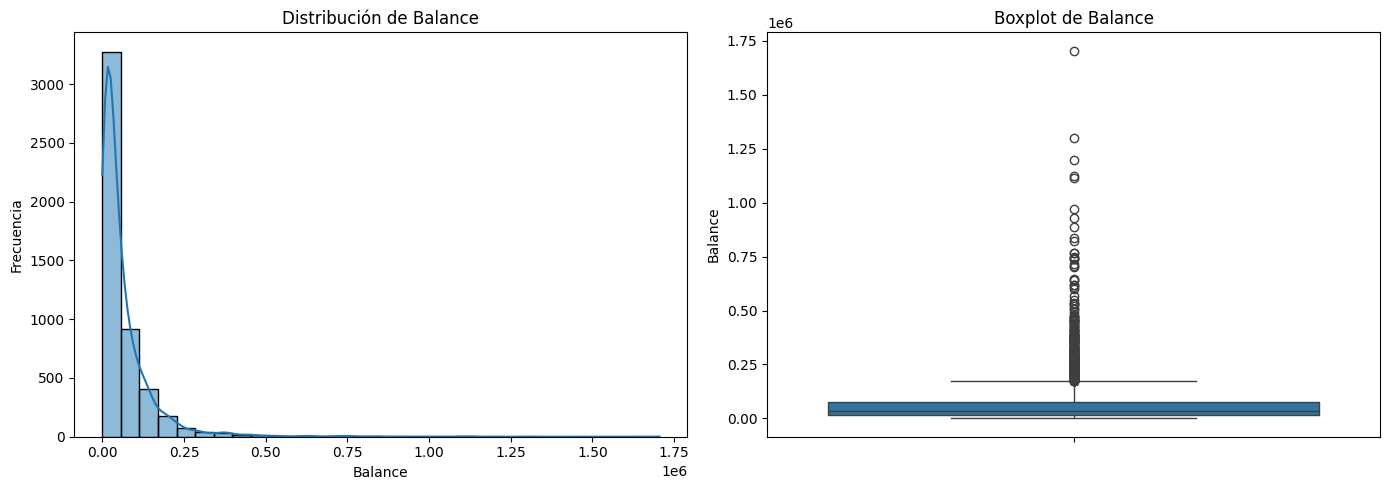

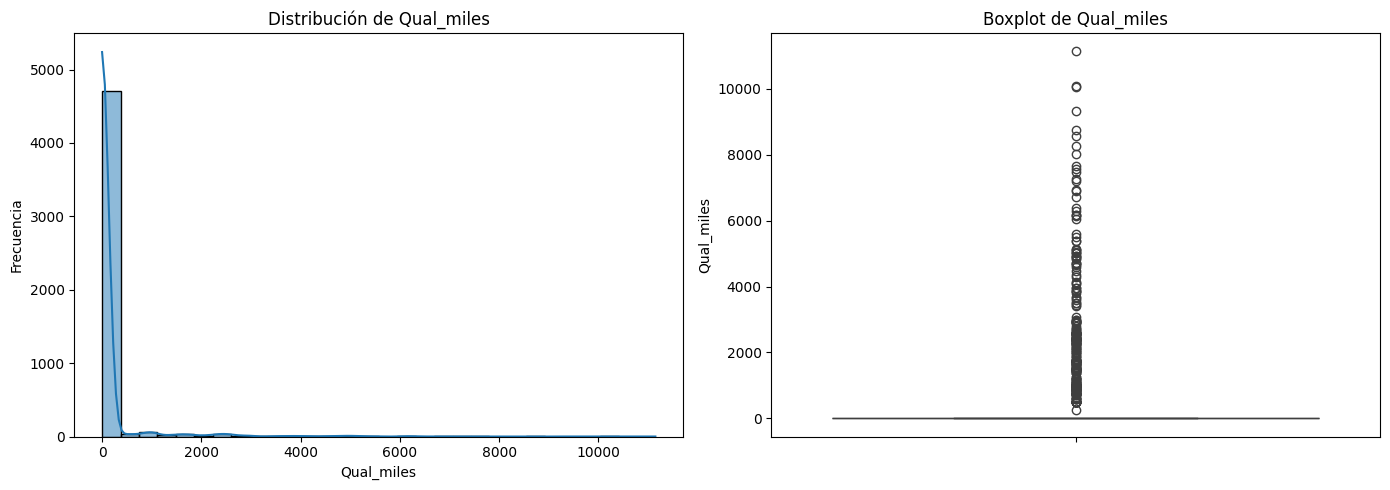

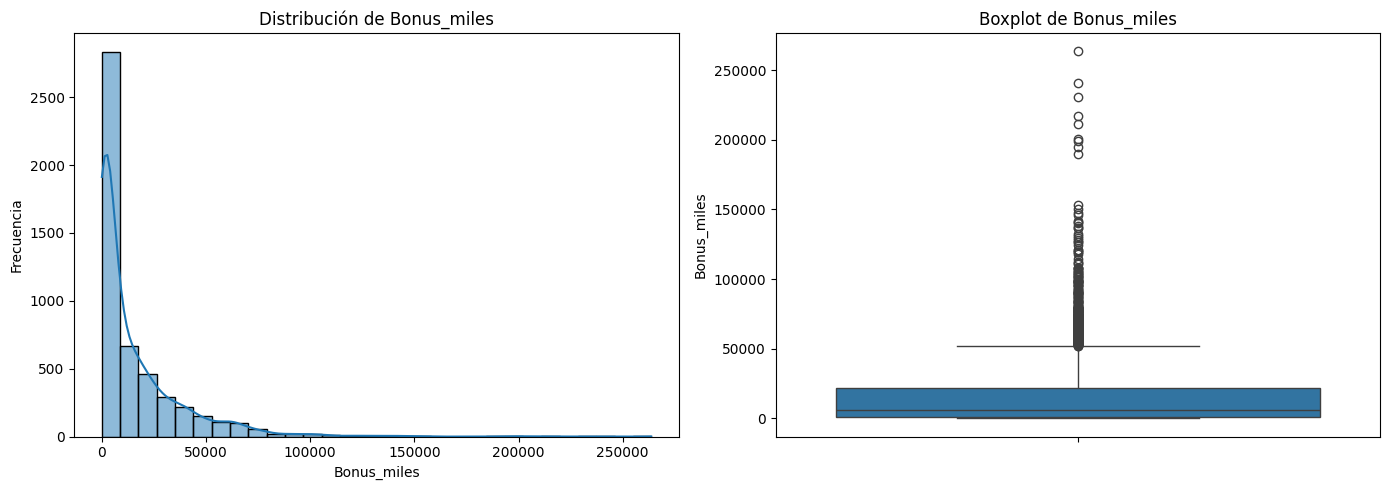

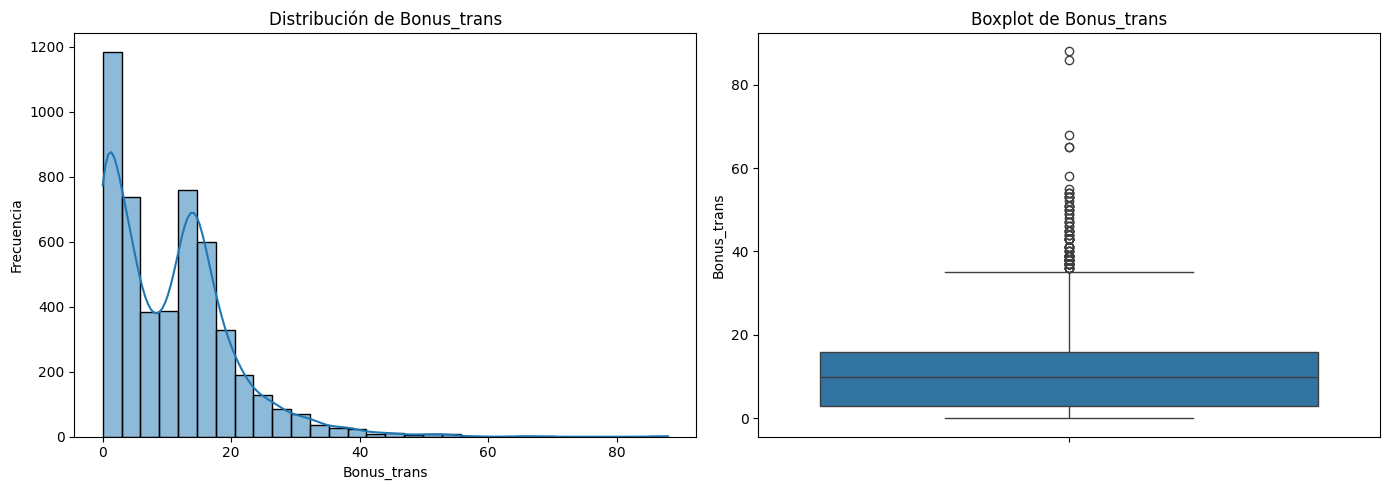

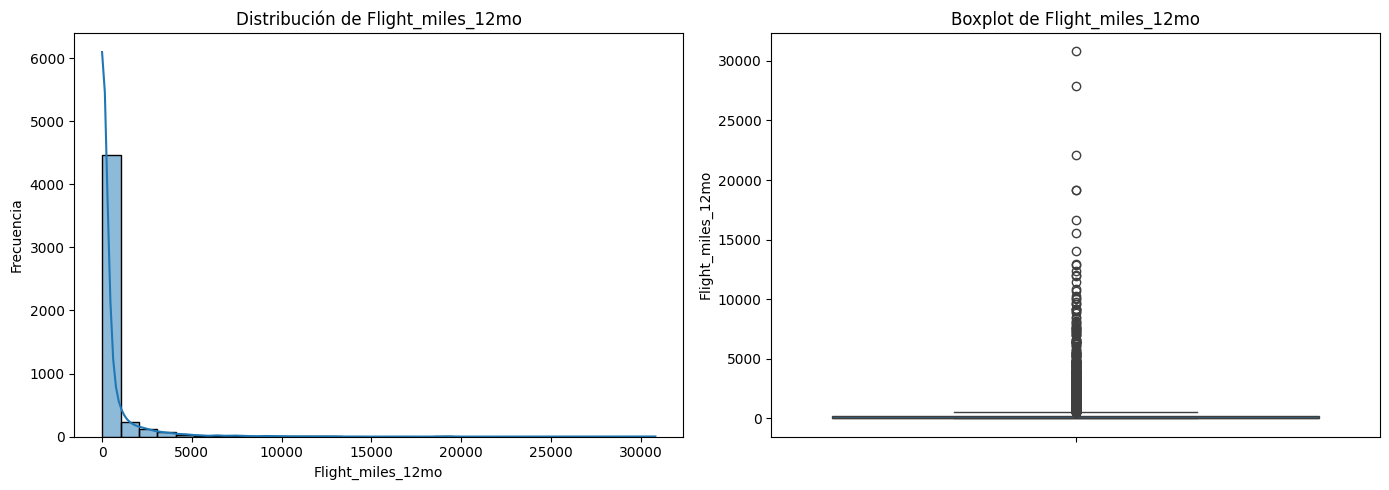

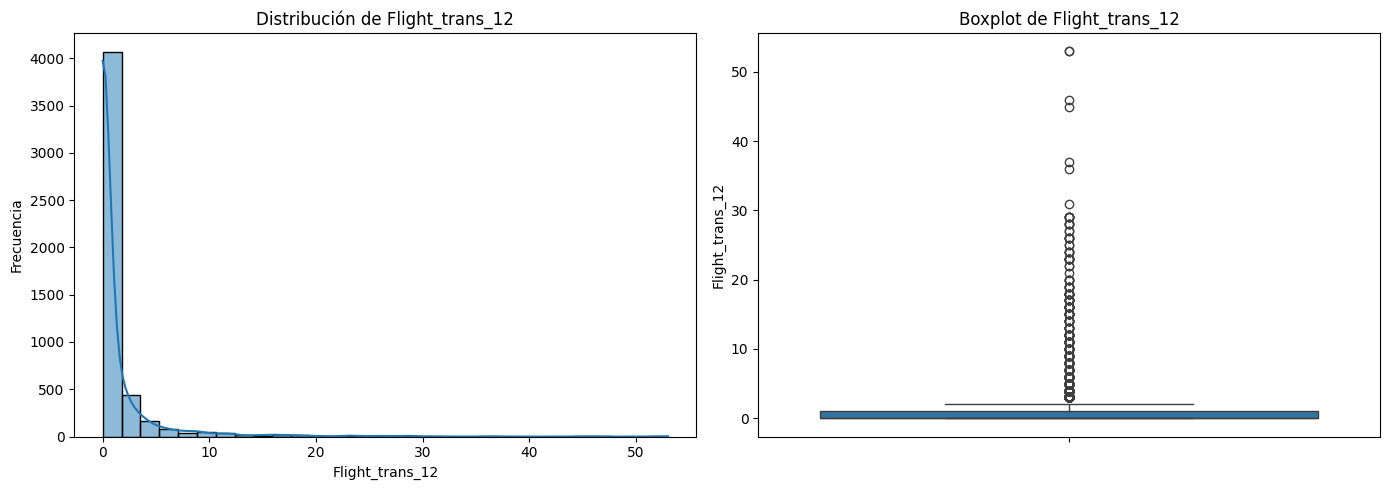

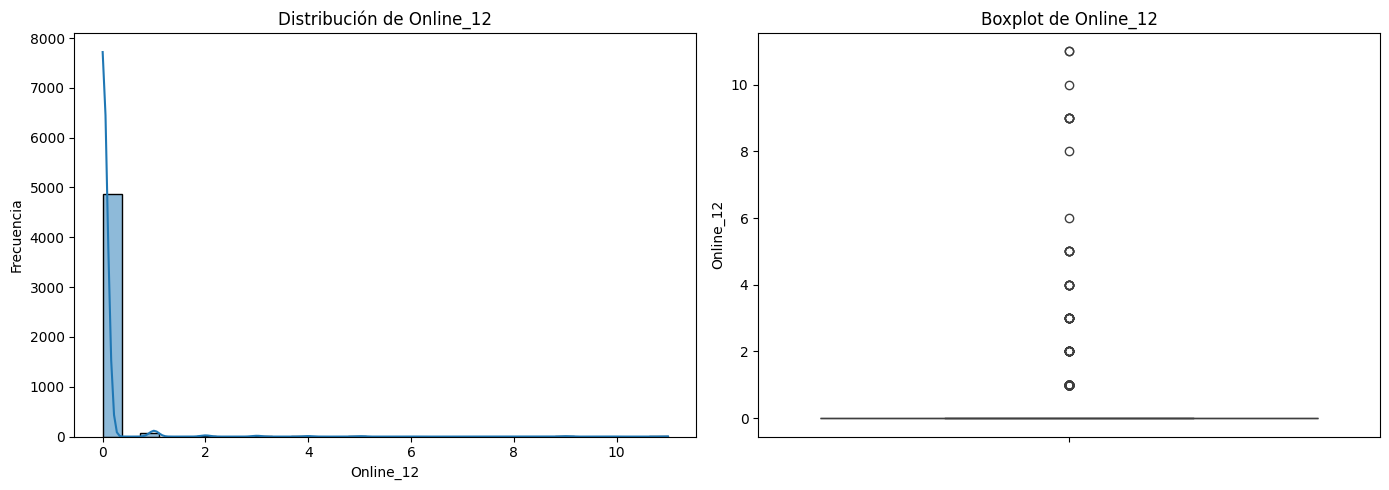

In [58]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

# Excluir 'ID#' si aún está presente y es solo un identificador
if 'ID#' in numeric_cols:
    numeric_cols.remove('ID#')

# Crear histogramas y boxplots para las variables numéricas
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(data[col], kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    sns.boxplot(y=data[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

Los histogramas y boxplots para las variables numéricas nos revelan lo siguiente:

*   **Distribuciones Asimétricas (Sesgo a la Derecha):** Para la mayoría de las variables como `Balance`, `Bonus_miles`, `Bonus_trans`, `Flight_miles_12mo`, `Flight_trans_12`, y `Online_12`, los histogramas muestran que la mayoría de los valores se concentran en el extremo inferior (cerca de cero) y las distribuciones tienen una cola larga hacia la derecha. Esto indica un fuerte sesgo positivo, donde hay pocos clientes con valores muy altos (por ejemplo, muchas millas o transacciones) y la mayoría con valores más bajos.

*   **Presencia de Outliers (Valores Atípicos):** Los boxplots confirman la presencia de numerosos valores atípicos, representados por puntos individuales fuera de los "bigotes" de la caja. Esto es particularmente evidente en variables como `Balance`, `Qual_miles`, `Bonus_miles` y `Flight_miles_12mo`, lo que sugiere que hay un pequeño grupo de clientes con una actividad excepcionalmente alta.

*   **Datos Concentrados en Cero (Sparsidad):** Variables como `Qual_miles`, `Flight_miles_12mo`, `Flight_trans_12` y `Online_12` muestran una alta frecuencia de valores en cero en sus histogramas. Esto significa que una proporción significativa de los clientes no tiene millas calificadas, no ha volado o no ha realizado compras en línea en los últimos 12 meses. Los boxplots para estas variables a menudo muestran que la mediana y los cuartiles inferiores están en cero.

Estas observaciones refuerzan la necesidad de un preprocesamiento de datos, como la transformación de variables o el manejo de outliers, para asegurar que estas distribuciones sesgadas y la presencia de ceros no afecten negativamente el rendimiento del modelo predictivo.

###**1.2.2. Visualización de Variables Categóricas**

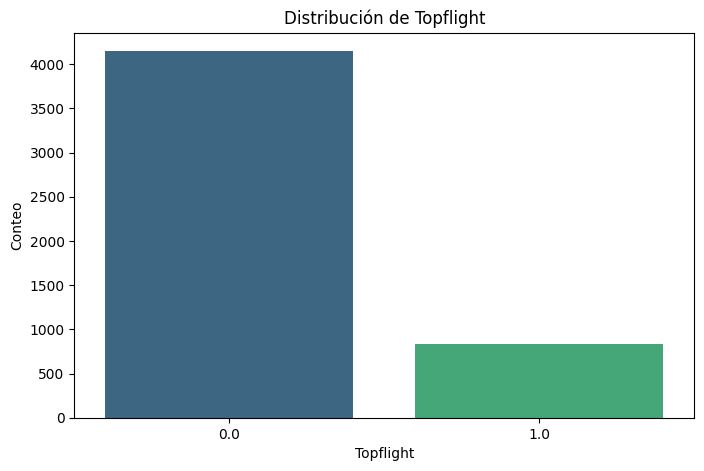

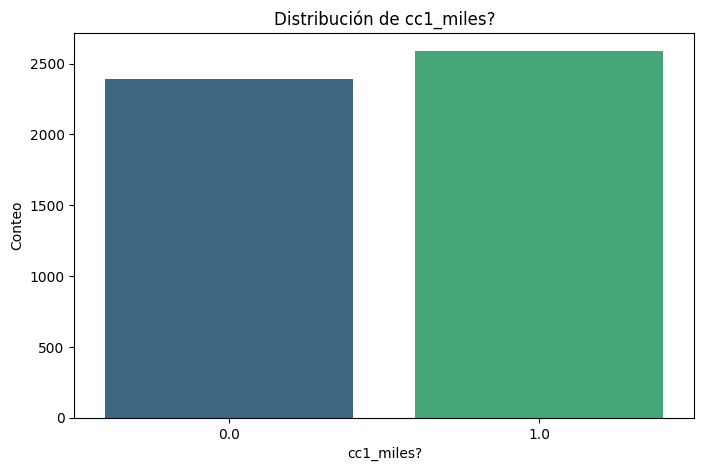

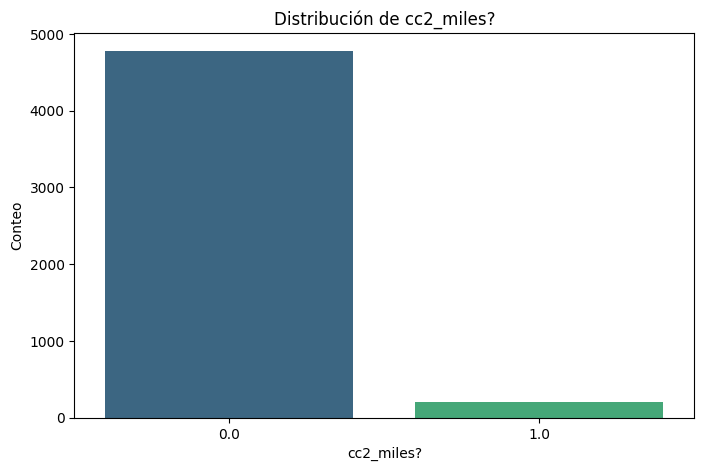

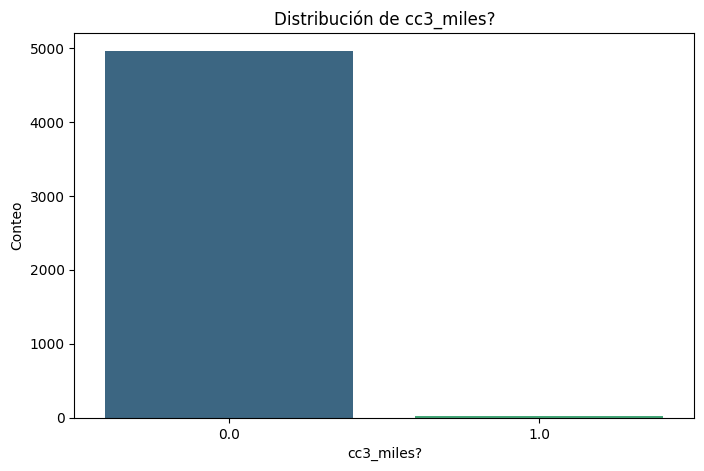

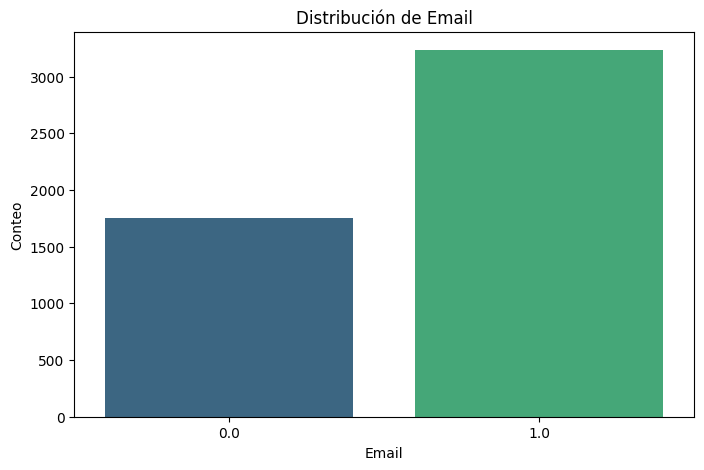

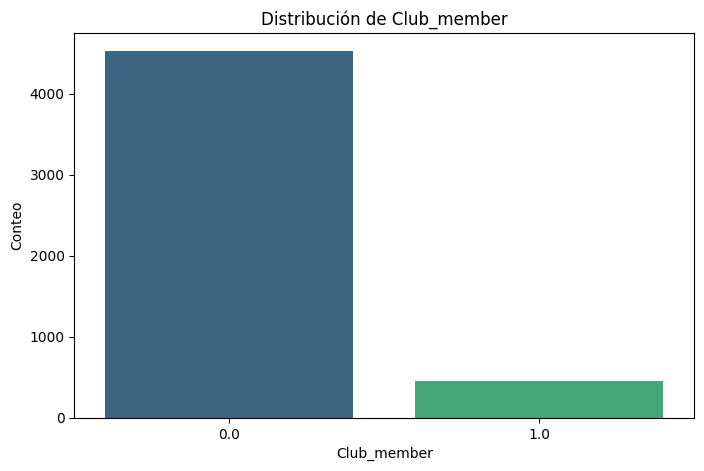

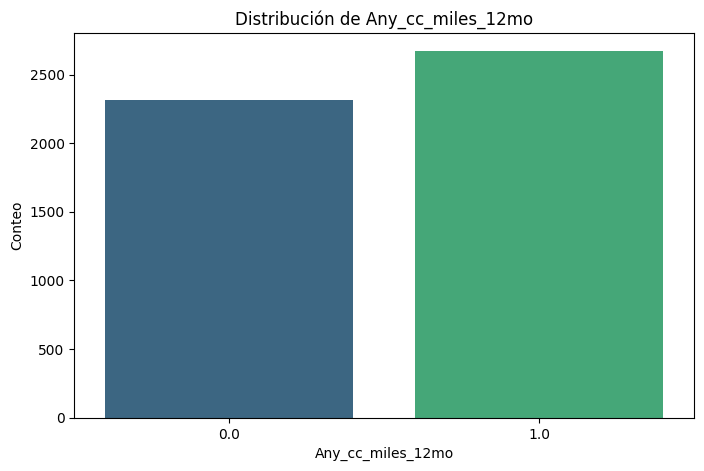

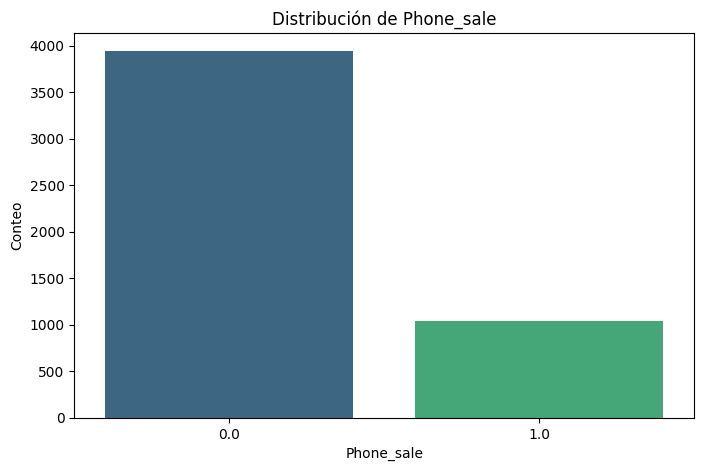

In [59]:
categorical_cols = data.select_dtypes(include='object').columns.tolist()

# Excluir 'ID#' si se manejó como object, aunque ya se excluyó de numeric
if 'ID#' in categorical_cols:
    categorical_cols.remove('ID#')

# Crear gráficos de barras para las variables categóricas
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=data, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.show()

Los gráficos de barras (countplot) para las variables categóricas nos revelan los siguientes puntos clave:

*   **Desequilibrio de Clases:** Se observa un desequilibrio significativo en varias variables. Por ejemplo, en `Topflight`, la mayoría de los clientes no tienen este estatus. De manera similar, en `cc2_miles?` y `cc3_miles?`, una gran mayoría de clientes no han ganado millas con esas tarjetas de crédito, con `cc3_miles?` mostrando un desequilibrio particularmente extremo (casi todos los valores son 0).

*   **Variable Objetivo (`Phone_sale`):** La variable objetivo también muestra un fuerte desequilibrio, donde la mayoría de los clientes (aproximadamente el 80%) no realizaron la compra del servicio de telecomunicaciones (`Phone_sale = 0`). Este desequilibrio es crucial a considerar durante el modelado, ya que puede llevar a que un modelo prediga mayoritariamente la clase más frecuente si no se maneja adecuadamente (por ejemplo, con técnicas de sobremuestreo o submuestreo).

*   **`Email` y `Any_cc_miles_12mo`:** Estas variables muestran una distribución más equitativa, aunque aún con una ligera mayoría en una de las categorías. La mayoría de los clientes tienen correo electrónico y una ligera mayoría sí agregó millas con alguna tarjeta de crédito en los últimos 12 meses.

En resumen, el análisis univariado de las variables categóricas destaca la prevalencia de desequilibrio de clases, especialmente en la variable objetivo, lo cual es una consideración importante para las próximas etapas de preprocesamiento y construcción del modelo.

##**1.3. Análisis Multivariado**

### **1.3.1. Correlación entre Variables Numéricas**

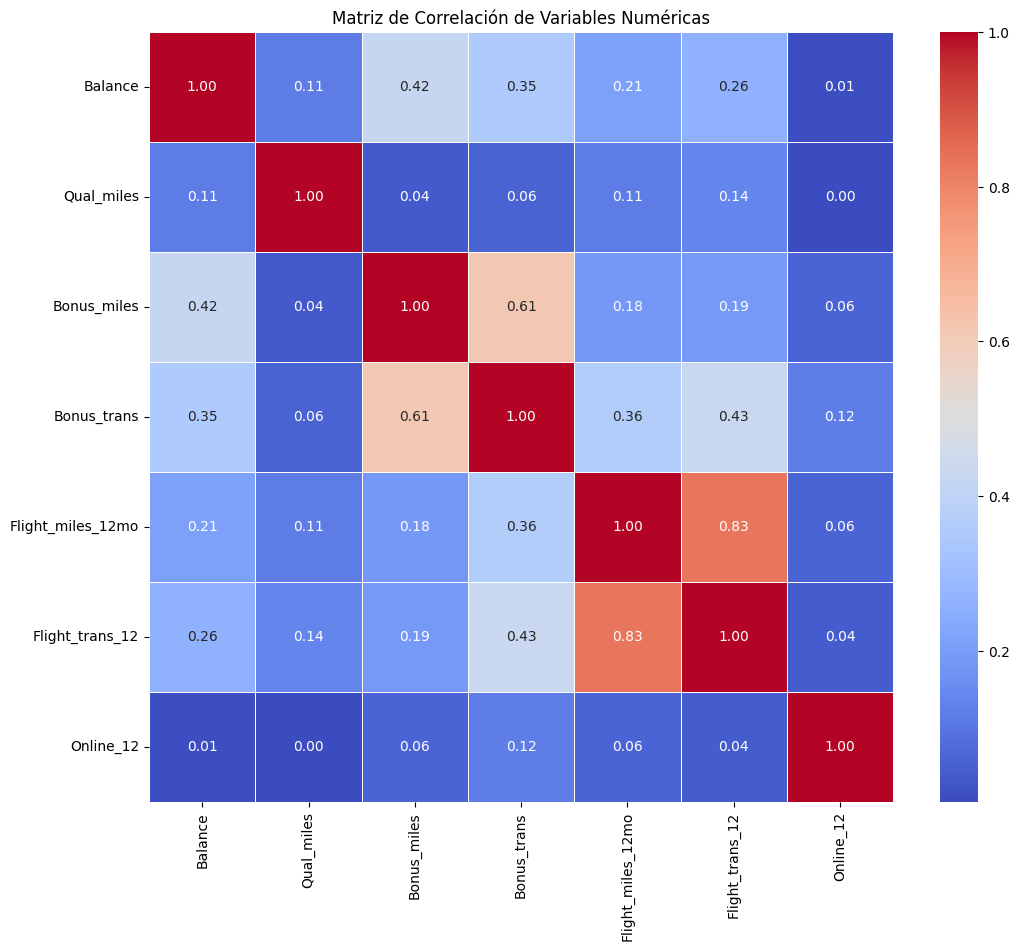

In [60]:
# Calcular la matriz de correlación para las variables numéricas
correlation_matrix = data[numeric_cols].corr()

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

El mapa de calor de correlación entre las variables numéricas nos revela las siguientes relaciones:

*   **Correlaciones Fuertes Positivas:**
    *   Existe una correlación muy fuerte entre `Flight_miles_12mo` y `Flight_trans_12` (0.83). Esto es lógico, ya que más millas voladas suelen implicar más transacciones de vuelo.
    *   También hay una correlación positiva fuerte entre `Bonus_miles` y `Bonus_trans` (0.61), indicando que más transacciones de bonificación generan más millas de bonificación.

*   **Correlaciones Moderadas Positivas:**
    *   `Balance` muestra correlaciones moderadas con `Bonus_miles` (0.42) y `Bonus_trans` (0.35). Esto sugiere que los clientes con un balance más alto tienden a tener más millas y transacciones de bonificación.

*   **Correlaciones Débiles o Nulas:**
    *   `Qual_miles` (millas de calificación) tiene correlaciones muy bajas con casi todas las demás variables numéricas, lo que sugiere que las millas de calificación se comportan de manera bastante independiente.
    *   `Online_12` también muestra correlaciones bajas con la mayoría de las variables, lo que indica que las compras en línea no están fuertemente ligadas a otras actividades de millas o transacciones.

Estas correlaciones nos dan una idea de qué variables numéricas se mueven juntas. Las correlaciones altas (como entre `Flight_miles_12mo` y `Flight_trans_12`) podrían indicar redundancia y ser consideradas para la selección de características en la fase de modelado.

### **1.3.2. Relación entre Variables Categóricas y la Variable Objetivo (`Phone_sale`)**

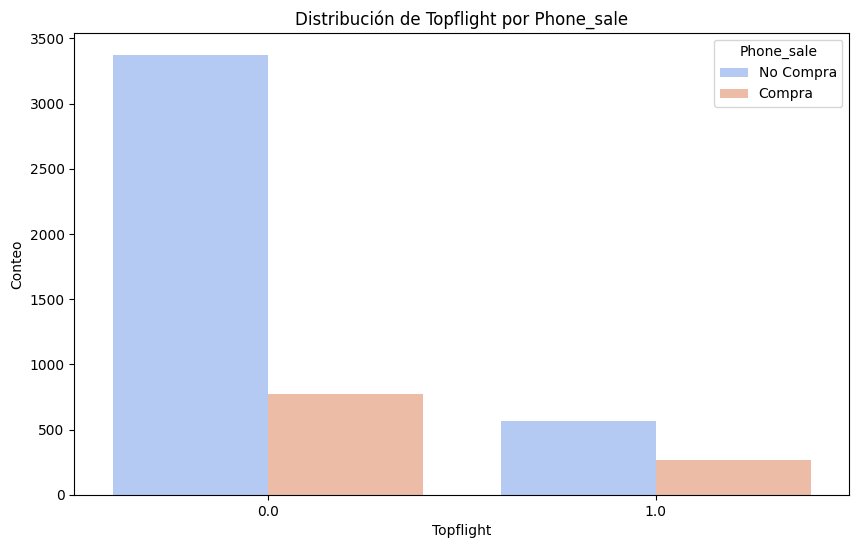

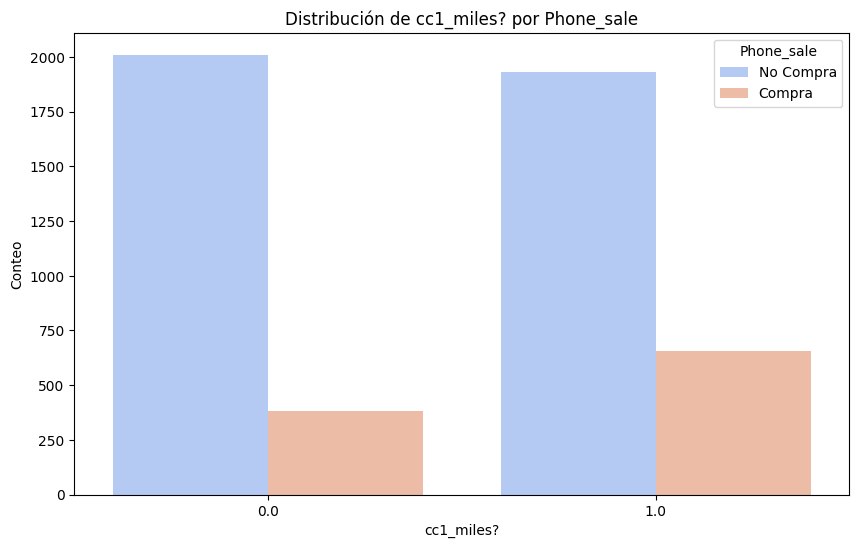

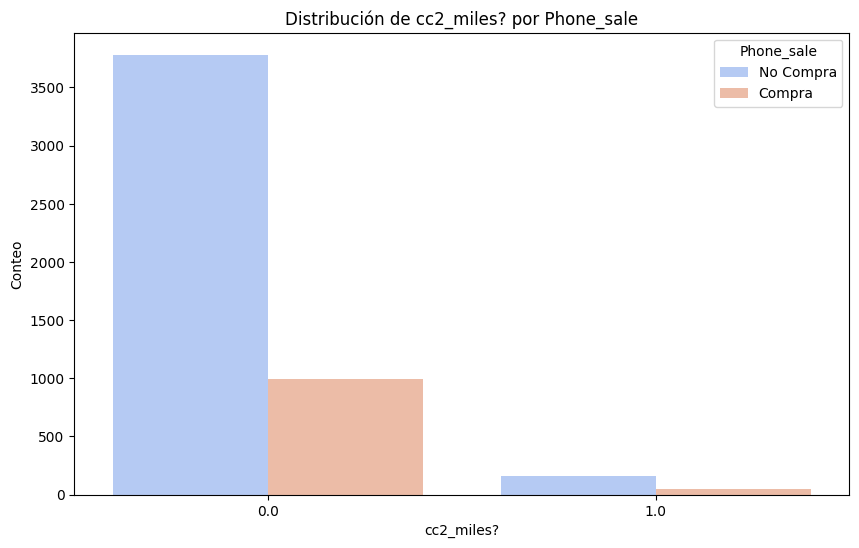

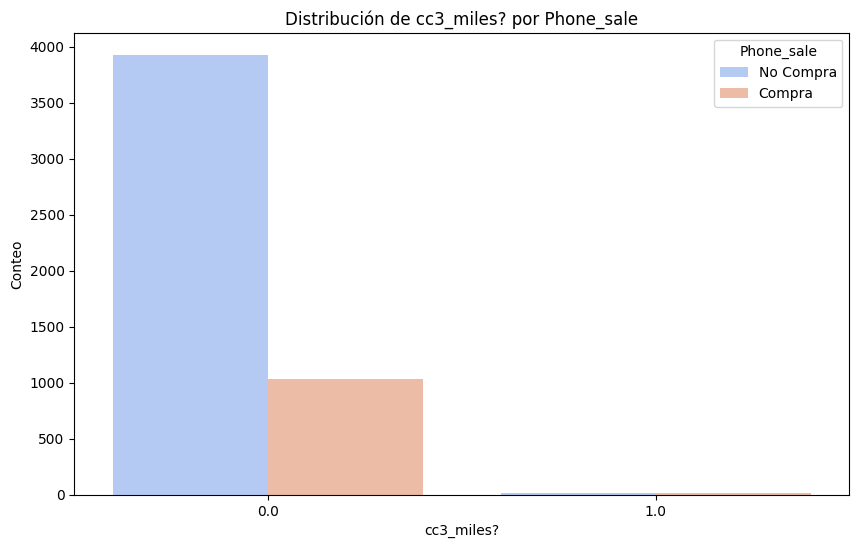

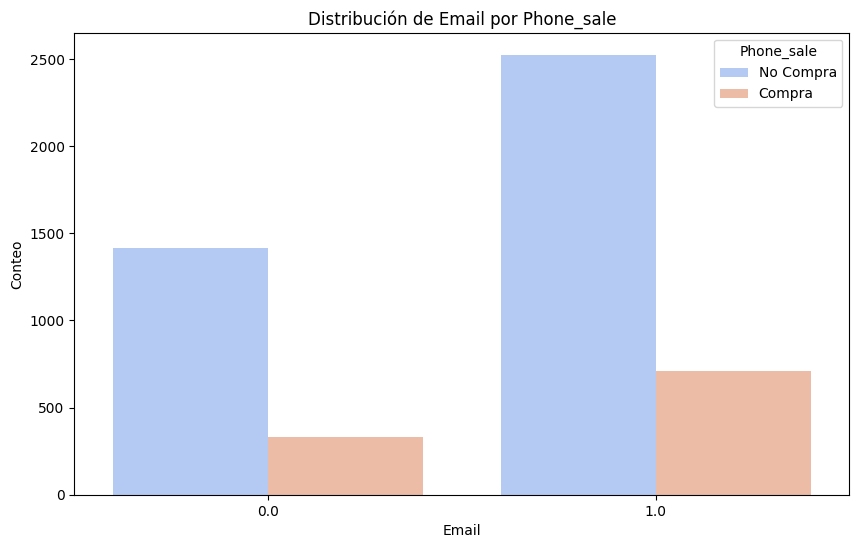

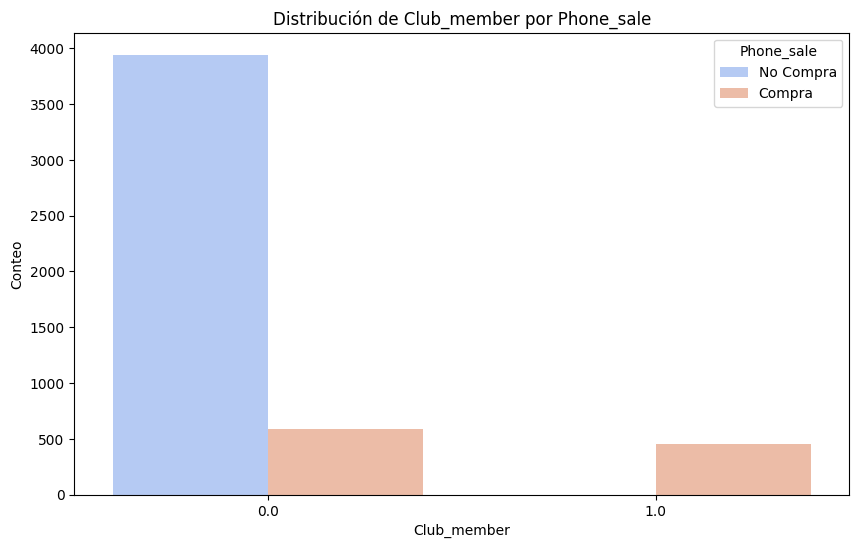

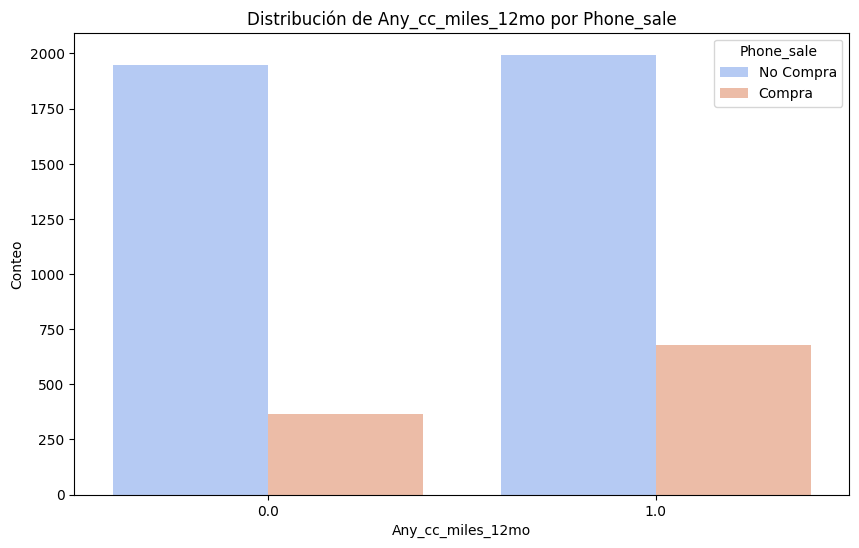

In [61]:
# Crear gráficos de barras para las variables categóricas en relación con 'Phone_sale'
for col in categorical_cols:
    if col != 'Phone_sale':  # Excluir la variable objetivo de ser comparada consigo misma
        plt.figure(figsize=(10, 6))
        sns.countplot(x=col, hue='Phone_sale', data=data, palette='coolwarm')
        plt.title(f'Distribución de {col} por Phone_sale')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.legend(title='Phone_sale', labels=['No Compra', 'Compra'])
        plt.show()

Los gráficos de barras que relacionan las variables categóricas con la variable objetivo `Phone_sale` revelan principalmente un **desequilibrio de clases** significativo. Esto significa que la mayoría de los clientes no compraron el servicio de telecomunicaciones (`Phone_sale = 0`).

Además, se observan algunas tendencias: categorías como tener estatus 'Topflight', haber ganado millas con `cc1_miles?`, tener un correo electrónico (`Email`), o ser miembro del club de la aerolínea (`Club_member`) muestran una ligera asociación con una mayor proporción de clientes que sí realizaron la compra (`Phone_sale = 1`). Esto sugiere que estas características podrían ser relevantes para predecir la compra del servicio.

###**1.3.3. Relación entre Variables Numéricas y la Variable Objetivo (`Phone_sale`)**

Para entender cómo las variables numéricas se distribuyen en relación con la variable objetivo `Phone_sale`, crearemos boxplots. Esto nos permitirá comparar las medianas, la dispersión y la presencia de valores atípicos para cada variable numérica, diferenciando entre los clientes que realizaron una compra y los que no.

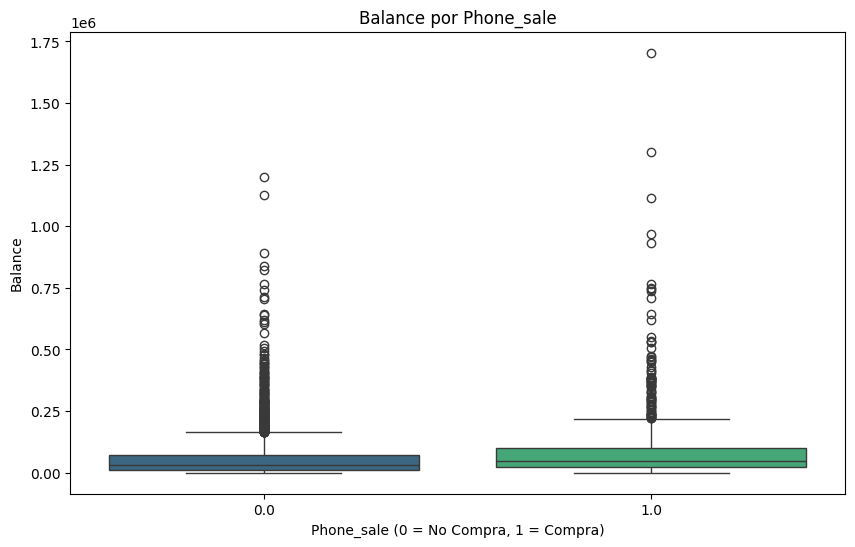

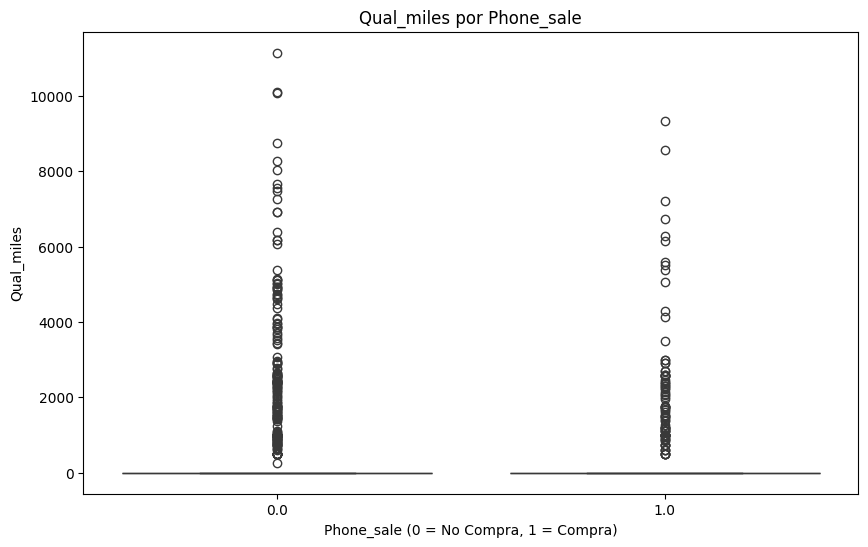

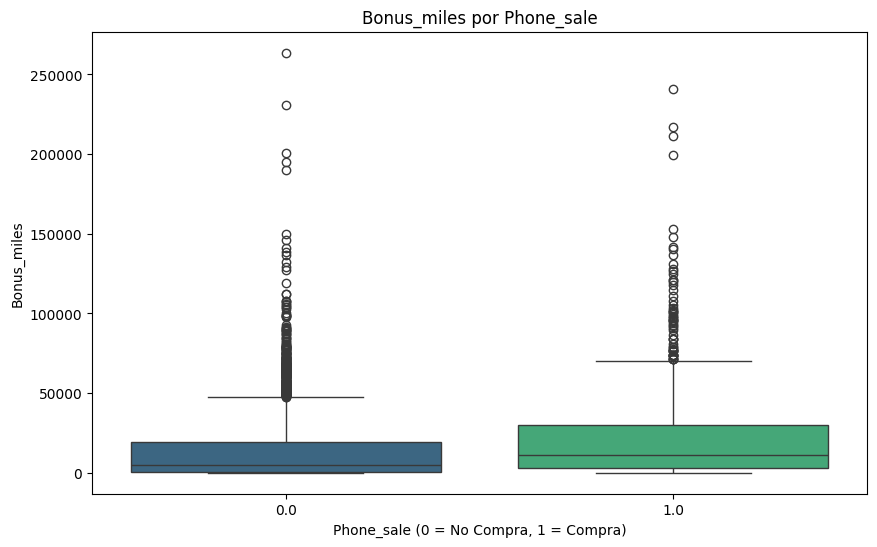

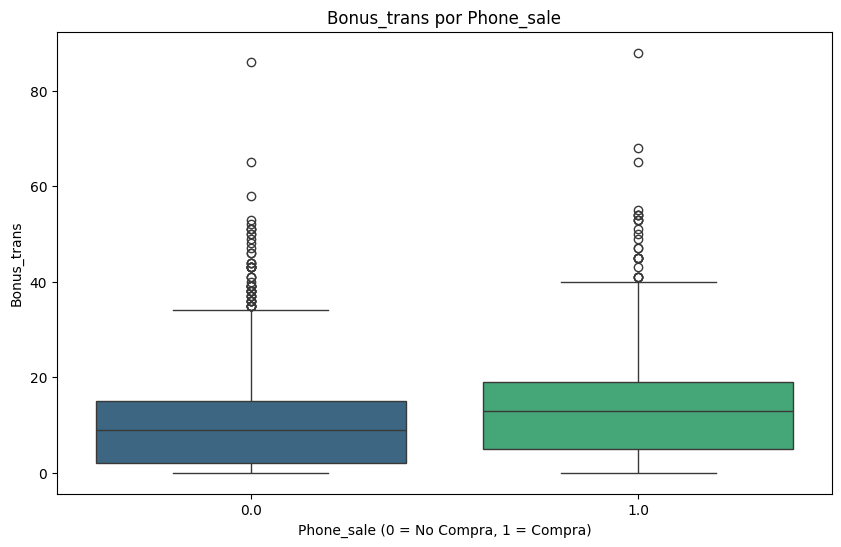

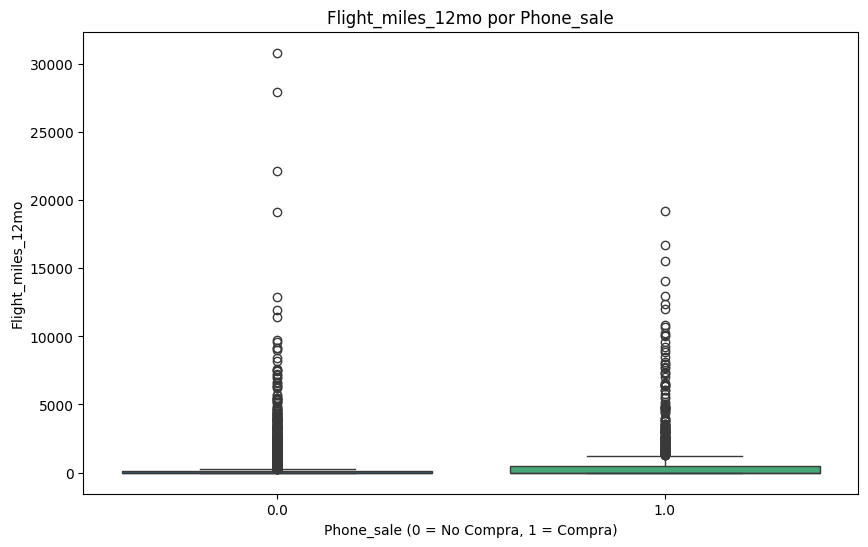

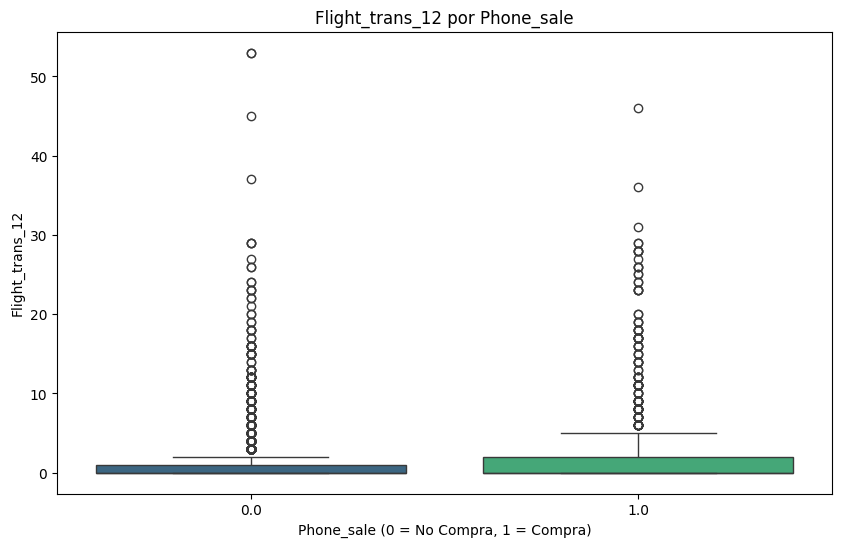

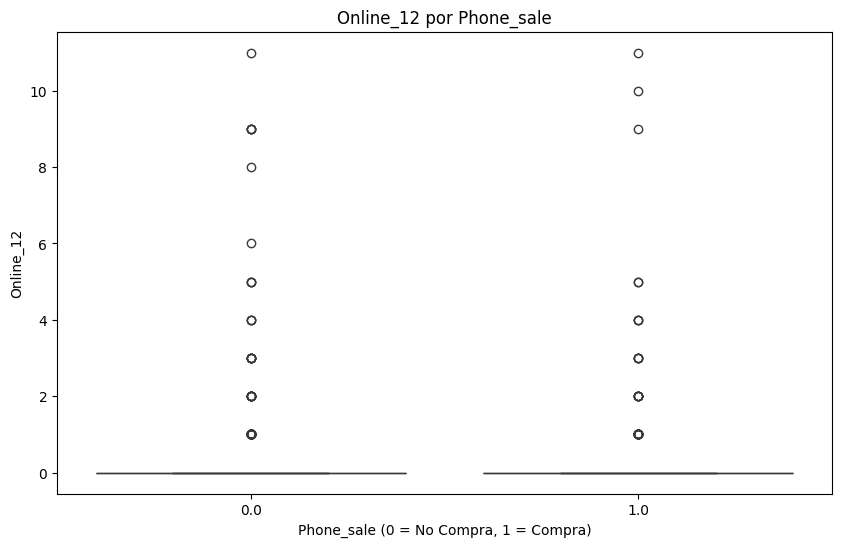

In [62]:
# Crear boxplots para las variables numéricas en relación con 'Phone_sale'
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Phone_sale', y=col, data=data, hue='Phone_sale', palette='viridis', legend=False)
    plt.title(f'{col} por Phone_sale')
    plt.xlabel('Phone_sale (0 = No Compra, 1 = Compra)')
    plt.ylabel(col)
    plt.show()

Los boxplots nos ofrecen una valiosa perspectiva sobre la relación entre las variables numéricas y la variable objetivo `Phone_sale` y podemos observar lo siguiente:

*   **Balance y Millas de Bonificación (`Balance`, `Bonus_miles`, `Bonus_trans`):** Generalmente, los clientes que realizan una compra (`Phone_sale = 1`) tienden a tener un `Balance` más alto y acumulan más `Bonus_miles` y `Bonus_trans` en comparación con aquellos que no compran (`Phone_sale = 0`). Las medianas de estas variables son a menudo más altas para `Phone_sale = 1`, y la distribución para este grupo puede mostrar una mayor dispersión o valores atípicos más altos.

*   **Millas de Vuelo y Transacciones de Vuelo (`Flight_miles_12mo`, `Flight_trans_12`):** De manera similar, los clientes que compraron el servicio muestran, en promedio, una mayor cantidad de `Flight_miles_12mo` y `Flight_trans_12`. Esto sugiere que una mayor actividad de vuelo podría estar asociada con la propensión a adquirir el servicio de telecomunicaciones.

*   **Millas Calificadas (`Qual_miles`):** Para `Qual_miles`, la diferencia entre ambos grupos puede ser menos pronunciada o los valores se concentran mucho en cero para ambos, lo que indica que esta variable podría no ser tan discriminatoria por sí sola.

*   **Compras Online (`Online_12`):** También se observa que los clientes con `Phone_sale = 1` podrían tener una mediana ligeramente más alta o una distribución más extendida en `Online_12`, aunque para muchas de estas variables la mayoría de los valores se concentran en cero para ambos grupos.

*   **Presencia de Outliers:** En casi todas las variables numéricas, se siguen observando numerosos valores atípicos, especialmente en el grupo `Phone_sale = 0`. Esto es consistente con el análisis univariado y refuerza la necesidad de manejar estos valores durante el preprocesamiento.

En este sentido, los clientes que compraron el servicio (`Phone_sale = 1`) a menudo presentan valores más altos en métricas relacionadas con la actividad de millas y transacciones, como `Balance`, `Bonus_miles`, `Bonus_trans`, `Flight_miles_12mo` y `Flight_trans_12`. Estas diferencias en las distribuciones son indicativos clave de posibles predictores y serán muy útiles en la etapa de modelado.

# **2. Preprocesamiento de Datos**

## **2.1. Manejo de Variables Numéricas**

### **2.1.1. Manejo de Outliers y Transformación de Sesgo**

Como observamos en el análisis exploratorio, muchas de nuestras variables numéricas presentan una fuerte asimetría y la presencia de outliers. Para mitigar su impacto en el modelo, aplicaremos una transformación logarítmica (log1p) a las variables numéricas sesgadas. Esta transformación es útil para reducir la asimetría y la varianza de los datos, haciendo que su distribución sea más cercana a una normal.

Variables con alto sesgo (skewness > 0.75):
['Online_12', 'Flight_miles_12mo', 'Qual_miles', 'Flight_trans_12', 'Balance', 'Bonus_miles', 'Bonus_trans']

Sesgo de las variables después de la transformación:
Online_12            8.697300
Qual_miles           3.968371
Flight_trans_12      1.979230
Flight_miles_12mo    1.064788
Bonus_trans         -0.614421
Balance             -0.820860
Bonus_miles         -1.364391
dtype: float64


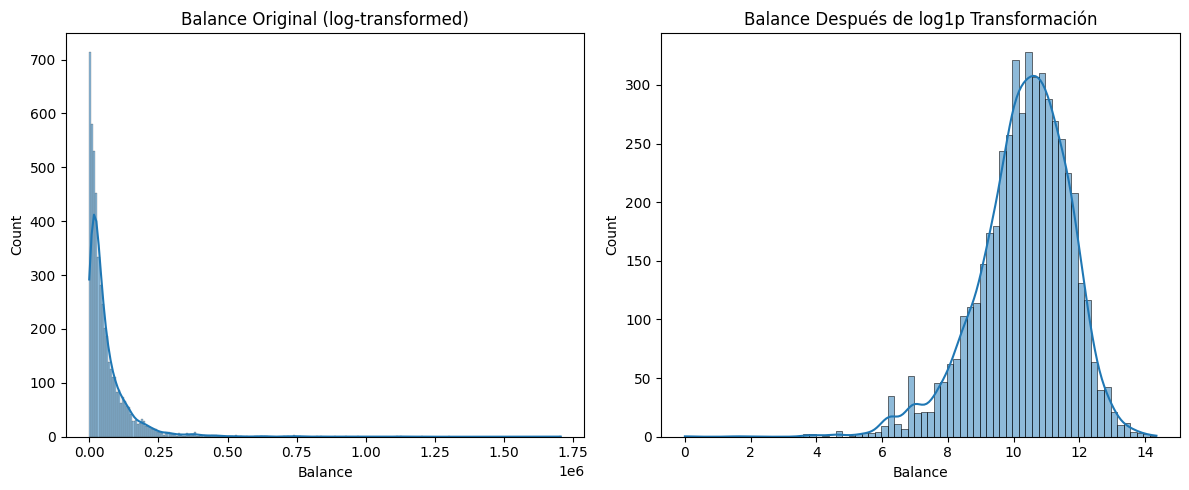

In [63]:
from scipy.stats import skew

# Identificar columnas numéricas, excluyendo 'ID#'
numeric_cols_for_transform = data[numeric_cols].drop(columns=['ID#'], errors='ignore').columns

# Calcular el sesgo de las variables numéricas
skewed_features = data[numeric_cols_for_transform].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

# Definir un umbral de sesgo. Un valor común es 0.75, pero se puede ajustar
skewness_threshold = 0.75
high_skew = skewed_features[skewed_features > skewness_threshold].index

print(f"Variables con alto sesgo (skewness > {skewness_threshold}):\n{high_skew.tolist()}")

# Aplicar transformación logarítmica (log1p) a las variables con alto sesgo
for feature in high_skew:
    data[feature] = np.log1p(data[feature])

print("\nSesgo de las variables después de la transformación:")
print(data[high_skew].apply(lambda x: skew(x.dropna())).sort_values(ascending=False))

# Visualizar la distribución de una variable antes y después de la transformación (ejemplo: Balance)
if 'Balance' in high_skew:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(data['Balance'].apply(lambda x: np.expm1(x)), kde=True)
    plt.title('Balance Original (log-transformed)')

    plt.subplot(1, 2, 2)
    sns.histplot(data['Balance'], kde=True)
    plt.title('Balance Después de log1p Transformación')
    plt.tight_layout()
    plt.show()

La transformación logarítmica **(log1p)** se aplicó a las variables numéricas con alto sesgo. Fue efectiva para reducir el sesgo en `Bonus_trans`, `Balance` y `Bonus_miles`. Sin embargo, variables como `Online_12`, `Qual_miles`, `Flight_trans_12` y `Flight_miles_12mo` aún mantienen un sesgo considerable, lo que indica la necesidad de considerar estrategias adicionales de preprocesamiento para estas últimas.

### **2.1.2. Escalado de Variables Numéricas (StandardScaler)**

Después de manejar el sesgo, el siguiente paso es escalar las variables numéricas. La estandarización (con `StandardScaler`) transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto es crucial para muchos algoritmos de Machine Learning que son sensibles a la escala de las características (por ejemplo, modelos basados en distancia como SVM, K-Means o redes neuronales), ya que evita que las características con rangos más grandes dominen el entrenamiento del modelo.

In [64]:
from sklearn.preprocessing import StandardScaler

# Las columnas numéricas ya fueron definidas anteriormente como `numeric_cols`
# Excluir 'ID#' si aún estuviera en la lista, ya que es un identificador y no debe escalarse
columns_to_scale = [col for col in numeric_cols if col != 'ID#']

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar el escalado a las columnas seleccionadas
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

print("Variables numéricas después del escalado (primeras 5 filas):")
display(data[columns_to_scale].head())

print("Estadísticas descriptivas después del escalado:")
display(data[columns_to_scale].describe())

Variables numéricas después del escalado (primeras 5 filas):


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12
0,-0.045526,-0.240317,-0.737639,-1.213190,-0.625317,-0.542117,-0.140402
1,-0.318145,-0.240317,-0.675293,-0.839111,-0.625317,-0.542117,-0.140402
2,0.230519,-0.240317,0.198271,-0.367827,-0.625317,-0.542117,-0.140402
3,-0.507631,-0.240317,-0.426097,-1.213190,-0.625317,-0.542117,-0.140402
4,0.847545,-0.240317,0.894726,1.188033,1.871766,1.690103,-0.140402


Estadísticas descriptivas después del escalado:


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12
count,4.985000e+03,4.985000e+03,4.985000e+03,4.985000e+03,4.985000e+03,4.985000e+03,4.985000e+03
mean,-5.929504e-16,5.131302e-17,2.280578e-17,-1.824463e-16,2.280578e-17,5.131302e-17,1.425362e-18
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-7.393943e+00,-2.403174e-01,-2.267416e+00,-1.852682e+00,-6.253174e-01,-5.421166e-01,-1.404017e-01
25%,-5.365530e-01,-2.403174e-01,-2.210871e-01,-5.736973e-01,-6.253174e-01,-5.421166e-01,-1.404017e-01
50%,1.045695e-01,-2.403174e-01,3.043965e-01,3.595983e-01,-6.253174e-01,-5.421166e-01,-1.404017e-01
75%,6.853205e-01,-2.403174e-01,6.863469e-01,7.612195e-01,1.108223e+00,4.192480e-01,-1.404017e-01
max,2.898041e+00,5.167947e+00,1.429824e+00,2.288501e+00,2.753259e+00,4.990429e+00,1.396792e+01


Después de aplicar StandardScaler, las variables numéricas ahora tienen una media de aproximadamente 0 y una desviación estándar de aproximadamente 1. Esto significa que los datos han sido centrados y escalados, lo cual es fundamental para el buen desempeño de muchos algoritmos de Machine Learning que son sensibles a la escala de las características.

## **2.2. Manejo de Variables Categóricas**

### **2.2.1. Codificación de Variables Categóricas (One-Hot Encoding)**

Para preparar las variables categóricas para los modelos de Machine Learning, es necesario convertirlas a un formato numérico. Utilizaremos One-Hot Encoding, que crea nuevas columnas binarias para cada categoría única en las variables originales. Esto es adecuado para variables nominales y evita que el modelo interprete erróneamente un orden entre categorías que no existe. La variable objetivo `Phone_sale` se excluirá de esta codificación.

In [65]:
# Identificar columnas categóricas (excluyendo 'ID#' si se considera categórico y la variable objetivo)
categorical_cols_to_encode = [col for col in categorical_cols if col != 'Phone_sale' and col != 'ID#']

# Aplicar One-Hot Encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

print("DataFrame después del One-Hot Encoding (primeras 5 filas):")
display(data_encoded.head())

print("Información del DataFrame después del One-Hot Encoding:")
data_encoded.info()

DataFrame después del One-Hot Encoding (primeras 5 filas):


,ID#,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Phone_sale,Topflight_1.0,cc1_miles?_1.0,cc2_miles?_1.0,cc3_miles?_1.0,Email_1.0,Club_member_1.0,Any_cc_miles_12mo_1.0
0,1.0,-0.045526,-0.240317,-0.737639,-1.213190,-0.625317,-0.542117,-0.140402,0.0,0,0,1,0,1,0,1
1,2.0,-0.318145,-0.240317,-0.675293,-0.839111,-0.625317,-0.542117,-0.140402,0.0,0,0,0,0,0,0,0
2,3.0,0.230519,-0.240317,0.198271,-0.367827,-0.625317,-0.542117,-0.140402,0.0,0,1,0,0,1,0,1
3,4.0,-0.507631,-0.240317,-0.426097,-1.213190,-0.625317,-0.542117,-0.140402,0.0,0,0,0,0,1,0,0
4,5.0,0.847545,-0.240317,0.894726,1.188033,1.871766,1.690103,-0.140402,0.0,1,1,0,0,1,0,1


Información del DataFrame después del One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4985 entries, 0 to 4984
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID#                    4985 non-null   float64
 1   Balance                4985 non-null   float64
 2   Qual_miles             4985 non-null   float64
 3   Bonus_miles            4985 non-null   float64
 4   Bonus_trans            4985 non-null   float64
 5   Flight_miles_12mo      4985 non-null   float64
 6   Flight_trans_12        4985 non-null   float64
 7   Online_12              4985 non-null   float64
 8   Phone_sale             4985 non-null   object 
 9   Topflight_1.0          4985 non-null   int64  
 10  cc1_miles?_1.0         4985 non-null   int64  
 11  cc2_miles?_1.0         4985 non-null   int64  
 12  cc3_miles?_1.0         4985 non-null   int64  
 13  Email_1.0              4985 non-null   int64  
 14  

Después del One-Hot Encoding, las variables categóricas se han transformado en múltiples columnas binarias (0 o 1). Esto permite que los modelos de Machine Learning las procesen como datos numéricos, sin implicar un orden artificial entre las categorías. Nuestra variable objetivo `Phone_sale` no fue modificada.

## **2.3. Manejo del Desequilibrio de Clases**

Como se observó en el análisis exploratorio, la variable objetivo `Phone_sale` presenta un desequilibrio significativo (la mayoría de los clientes no realizaron la compra). Para evitar que el modelo se sesgue hacia la clase mayoritaria y asegurar un buen rendimiento en la predicción de ambas clases, aplicaremos técnicas de remuestreo. Utilizaré **SMOTE (Synthetic Minority Over-sampling Technique)** para generar nuevas muestras sintéticas de la clase minoritaria (clientes que compraron el servicio), equilibrando así la distribución de clases en el conjunto de entrenamiento.

In [66]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Separar las características (X) y la variable objetivo (y)
# Excluimos 'ID#' ya que es un identificador y no debe usarse para el modelado
X = data_encoded.drop(columns=['ID#', 'Phone_sale'])
y = data_encoded['Phone_sale']

# Convertir la variable objetivo 'y' a tipo numérico si aún es 'object'
y = y.astype(int)

print(f"Distribución de clases antes de SMOTE: {Counter(y)}")

# Inicializar SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE a los datos
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Distribución de clases después de SMOTE: {Counter(y_resampled)}")

print("Primeras 5 filas de las características después de SMOTE:")
display(X_resampled.head())
print("Primeras 5 filas de la variable objetivo después de SMOTE:")
display(y_resampled.head())

Distribución de clases antes de SMOTE: Counter({0: 3943, 1: 1042})
Distribución de clases después de SMOTE: Counter({0: 3943, 1: 3943})
Primeras 5 filas de las características después de SMOTE:


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Topflight_1.0,cc1_miles?_1.0,cc2_miles?_1.0,cc3_miles?_1.0,Email_1.0,Club_member_1.0,Any_cc_miles_12mo_1.0
0,-0.045526,-0.240317,-0.737639,-1.213190,-0.625317,-0.542117,-0.140402,0,0,1,0,1,0,1
1,-0.318145,-0.240317,-0.675293,-0.839111,-0.625317,-0.542117,-0.140402,0,0,0,0,0,0,0
2,0.230519,-0.240317,0.198271,-0.367827,-0.625317,-0.542117,-0.140402,0,1,0,0,1,0,1
3,-0.507631,-0.240317,-0.426097,-1.213190,-0.625317,-0.542117,-0.140402,0,0,0,0,1,0,0
4,0.847545,-0.240317,0.894726,1.188033,1.871766,1.690103,-0.140402,1,1,0,0,1,0,1


Primeras 5 filas de la variable objetivo después de SMOTE:


,Phone_sale
0,0
1,0
2,0
3,0
4,0


## **2.4. División de Datos (Training/Test Split)**

Después de preprocesar y balancear los datos, el siguiente paso es dividir el conjunto de datos en conjuntos de entrenamiento y prueba. El conjunto de entrenamiento se utilizará para entrenar el modelo, mientras que el conjunto de prueba se mantendrá separado para evaluar el rendimiento del modelo en datos no vistos. Esto ayuda a garantizar que el modelo generalice bien a nuevos datos y evita el sobreajuste.

In [67]:
from sklearn.model_selection import train_test_split

# Dividir los datos balanceados en conjuntos de entrenamiento y prueba
# Usaremos un 80% para entrenamiento y un 20% para prueba
# stratify=y_resampled asegura que la proporción de clases en y_resampled se mantenga en los conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print(f"\nDistribución de clases en y_train: {Counter(y_train)}")
print(f"Distribución de clases en y_test: {Counter(y_test)}")

Dimensiones de X_train: (6308, 14)
Dimensiones de y_train: (6308,)
Dimensiones de X_test: (1578, 14)
Dimensiones de y_test: (1578,)

Distribución de clases en y_train: Counter({1: 3154, 0: 3154})
Distribución de clases en y_test: Counter({0: 789, 1: 789})


El número total de muestras después de la división en `X_train` (6308) y `X_test` (1578) asciende a 7886, lo cual es superior a los 4985 registros originales del dataset. Este aumento se debe a la aplicación de la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, implementada previamente para manejar el desequilibrio de clases en la variable objetivo `Phone_sale`. SMOTE generó muestras sintéticas para la clase minoritaria (`Phone_sale = 1`) hasta igualar el número de muestras de la clase mayoritaria (`Phone_sale = 0`). Originalmente, teníamos 3943 casos de la clase 0 y 1042 de la clase 1. Tras SMOTE, ambas clases quedaron con 3943 muestras, sumando un total de 7886. Posteriormente, este conjunto balanceado fue dividido en un 80% para entrenamiento (aproximadamente 6308 muestras) y un 20% para prueba (aproximadamente 1578 muestras), manteniendo la proporción balanceada en ambos subconjuntos gracias al parámetro `stratify`.

## **2.5. Ingeniería de Características (Feature Engineering)**


In [68]:
# Epsilon pequeño para evitar división por cero en ratios
epsilon = 1e-6

# Feature Engineering en X_train
X_train['Total_Miles'] = X_train['Balance'] + X_train['Qual_miles'] + X_train['Bonus_miles']
X_train['Total_Transactions'] = X_train['Bonus_trans'] + X_train['Flight_trans_12']
X_train['Flight_Ratio'] = X_train['Flight_miles_12mo'] / (X_train['Flight_trans_12'] + epsilon)
X_train['Bonus_Ratio'] = X_train['Bonus_miles'] / (X_train['Bonus_trans'] + epsilon)
X_train['Online_to_Balance_Ratio'] = X_train['Online_12'] / (X_train['Balance'] + epsilon)

# Feature Engineering en X_test (aplicar las mismas transformaciones)
X_test['Total_Miles'] = X_test['Balance'] + X_test['Qual_miles'] + X_test['Bonus_miles']
X_test['Total_Transactions'] = X_test['Bonus_trans'] + X_test['Flight_trans_12']
X_test['Flight_Ratio'] = X_test['Flight_miles_12mo'] / (X_test['Flight_trans_12'] + epsilon)
X_test['Bonus_Ratio'] = X_test['Bonus_miles'] / (X_test['Bonus_trans'] + epsilon)
X_test['Online_to_Balance_Ratio'] = X_test['Online_12'] / (X_test['Balance'] + epsilon)

print("X_train después de Ingeniería de Características (primeras 5 filas):")
display(X_train.head())
print("X_test después de Ingeniería de Características (primeras 5 filas):")
display(X_test.head())

X_train después de Ingeniería de Características (primeras 5 filas):


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Topflight_1.0,cc1_miles?_1.0,cc2_miles?_1.0,cc3_miles?_1.0,Email_1.0,Club_member_1.0,Any_cc_miles_12mo_1.0,Total_Miles,Total_Transactions,Flight_Ratio,Bonus_Ratio,Online_to_Balance_Ratio
6389,1.274029,-0.240317,0.989141,1.334529,1.406762,0.419248,-0.140402,0,1,0,0,1,0,1,2.022852,1.753777,3.355433,0.741190,-0.110203
1934,1.351046,-0.240317,0.956891,1.153214,1.180838,0.981610,-0.140402,1,1,0,0,1,0,1,2.067620,2.134824,1.202959,0.829759,-0.103921
6460,-0.012836,-0.240317,0.956556,0.804217,-0.625317,-0.542117,-0.140402,0,1,0,0,0,0,1,0.703402,0.262100,1.153476,1.189423,10.939028
1828,-2.386064,-0.240317,0.498917,0.174461,-0.625317,-0.542117,-0.140402,0,1,0,0,1,0,1,-2.127464,-0.367656,1.153476,2.859748,0.058842
3099,0.177904,-0.240317,-0.219906,-0.839111,1.634315,0.981610,-0.140402,0,0,0,0,1,0,0,-0.282319,0.142500,1.664930,0.262070,-0.789193


X_test después de Ingeniería de Características (primeras 5 filas):


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Topflight_1.0,cc1_miles?_1.0,cc2_miles?_1.0,cc3_miles?_1.0,Email_1.0,Club_member_1.0,Any_cc_miles_12mo_1.0,Total_Miles,Total_Transactions,Flight_Ratio,Bonus_Ratio,Online_to_Balance_Ratio
3590,-1.360292,-0.240317,0.002019,0.359598,-0.625317,-0.542117,-0.140402,0,0,0,0,0,0,0,-1.598591,-0.182518,1.153476,0.005613,0.103214
4405,-1.431961,-0.240317,-0.275149,-0.839111,-0.625317,-0.542117,-0.140402,0,0,1,0,1,0,1,-1.947427,-1.381227,1.153476,0.327906,0.098049
5562,0.925742,-0.240317,1.363048,1.111235,-0.625317,-0.542117,-0.140402,0,1,0,0,1,0,1,2.048472,0.569118,1.153476,1.226605,-0.151664
1481,1.189451,-0.240317,0.908179,0.863835,-0.625317,-0.542117,-0.140402,0,1,0,0,1,0,1,1.857313,0.321719,1.153476,1.051332,-0.118039
216,-2.226678,-0.240317,-0.183875,0.271666,-0.625317,-0.542117,-0.140402,0,1,1,0,0,0,1,-2.650870,-0.270451,1.153476,-0.676841,0.063054


Mediante la ingeniería de características se proporciona al modelo información más rica y potencialmente capturar relaciones que las variables originales no mostraban. Específicamente, se crearon:

*   `Total_Miles`: Suma de diferentes tipos de millas (`Balance`, `Qual_miles`, `Bonus_miles`) para representar la actividad total de millas.
*   `Total_Transactions`: Suma de las transacciones de bonificación y de vuelo (`Bonus_trans`, `Flight_trans_12`) para capturar la actividad transaccional general.
*   `Flight_Ratio`: Relación entre las millas de vuelo y las transacciones de vuelo (`Flight_miles_12mo` / `Flight_trans_12`) para indicar la eficiencia o el valor promedio por transacción de vuelo.
*   `Bonus_Ratio`: Relación entre las millas de bonificación y las transacciones de bonificación (`Bonus_miles` / `Bonus_trans`) para medir la eficiencia en la acumulación de millas de bonificación.
*   `Online_to_Balance_Ratio`: Relación entre las compras en línea y el saldo total (`Online_12` / `Balance`) para entender la proporción de la actividad en línea respecto al balance general del cliente.

Estas nuevas características buscan ofrecer al modelo una visión más consolidada y expresiva de los patrones de comportamiento de los clientes.

# **3. Modelado Predictivo**

## **3.1. Entrenamiento de Modelos de Clasificación**

### **3.1.1. Regresión Logística**

Es un algoritmo de clasificación lineal ampliamente utilizado. A pesar de su nombre, la regresión logística se utiliza para predecir la probabilidad de que una instancia pertenezca a una clase en particular. Es un buen punto de partida debido a su interpretabilidad y eficiencia.

In [69]:
from sklearn.linear_model import LogisticRegression

# Inicializar el modelo de Regresión Logística
# Se ajusta max_iter para asegurar la convergencia y solver 'liblinear' es bueno para datasets pequeños
logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Entrenar el modelo con los datos de entrenamiento
logistic_model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

Modelo de Regresión Logística entrenado exitosamente.


Evalúo el rendimiento del modelo de Regresión Logística utilizando métricas de clasificación comunes como la precisión (accuracy), la exhaustividad (recall), la puntuación F1 y la matriz de confusión. Esto nos dará una comprensión clara de cómo el modelo predice la variable objetivo (`Phone_sale`).

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Realizar predicciones sobre el conjunto de prueba
y_pred_logreg = logistic_model.predict(X_test)
y_proba_logreg = logistic_model.predict_proba(X_test)[:, 1]

# Calcular métricas de evaluación
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print("--- Evaluación del Modelo de Regresión Logística ---")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")
print(f"F1-Score: {f1_logreg:.4f}")
print(f"ROC AUC Score: {roc_auc_logreg:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_logreg))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_logreg))

--- Evaluación del Modelo de Regresión Logística ---
Accuracy: 0.7237
Precision: 0.8779
Recall: 0.5196
F1-Score: 0.6529
ROC AUC Score: 0.8063

Matriz de Confusión:
[[732  57]
 [379 410]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.66      0.93      0.77       789
           1       0.88      0.52      0.65       789

    accuracy                           0.72      1578
   macro avg       0.77      0.72      0.71      1578
weighted avg       0.77      0.72      0.71      1578



###**3.1.2. Árbol de Decisión**

Un Árbol de Decisión es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza para tareas de clasificación y regresión. Construye un modelo de predicción en forma de estructura de árbol, donde cada nodo interno representa una 'prueba' en un atributo, cada rama representa el resultado de la prueba y cada nodo hoja representa una etiqueta de clase.

In [71]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar el modelo de Árbol de Decisión
dtree_model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
dtree_model.fit(X_train, y_train)

# Realizar predicciones
y_pred_dtree = dtree_model.predict(X_test)
y_proba_dtree = dtree_model.predict_proba(X_test)[:, 1]

# Calcular métricas
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
precision_dtree = precision_score(y_test, y_pred_dtree)
recall_dtree = recall_score(y_test, y_pred_dtree)
f1_dtree = f1_score(y_test, y_pred_dtree)
roc_auc_dtree = roc_auc_score(y_test, y_proba_dtree)

print("--- Evaluación del Modelo de Árbol de Decisión ---")
print(f"Accuracy: {accuracy_dtree:.4f}")
print(f"Precision: {precision_dtree:.4f}")
print(f"Recall: {recall_dtree:.4f}")
print(f"F1-Score: {f1_dtree:.4f}")
print(f"ROC AUC Score: {roc_auc_dtree:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_dtree))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_dtree))

--- Evaluación del Modelo de Árbol de Decisión ---
Accuracy: 0.8264
Precision: 0.8191
Recall: 0.8378
F1-Score: 0.8283
ROC AUC Score: 0.8265

Matriz de Confusión:
[[643 146]
 [128 661]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       789
           1       0.82      0.84      0.83       789

    accuracy                           0.83      1578
   macro avg       0.83      0.83      0.83      1578
weighted avg       0.83      0.83      0.83      1578



###**3.1.3 Random Forest**

Random Forest es un algoritmo de aprendizaje conjunto (ensemble learning) que construye múltiples árboles de decisión durante el entrenamiento y genera la clase que es la moda de las clases (clasificación) o la predicción media (regresión) de los árboles individuales. Es conocido por su capacidad para manejar el sobreajuste y su buen rendimiento general.

In [72]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("--- Evaluación del Modelo Random Forest ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

--- Evaluación del Modelo Random Forest ---
Accuracy: 0.8764
Precision: 0.8949
Recall: 0.8530
F1-Score: 0.8735
ROC AUC Score: 0.9400

Matriz de Confusión:
[[710  79]
 [116 673]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       789
           1       0.89      0.85      0.87       789

    accuracy                           0.88      1578
   macro avg       0.88      0.88      0.88      1578
weighted avg       0.88      0.88      0.88      1578



## **3.2. Comparación de Modelos**

Para facilitar la selección del mejor modelo, consolidaremos las métricas clave de cada uno en una tabla comparativa. Esto nos permitirá visualizar directamente el rendimiento de la Regresión Logística, el Árbol de Decisión y Random Forest.

### **3.2.1. Curvas ROC AUC**

Las curvas ROC (Receiver Operating Characteristic) y el área bajo la curva (AUC) son métricas clave para evaluar el rendimiento de modelos de clasificación binaria. Nos ayudan a entender la capacidad de un modelo para distinguir entre clases, especialmente cuando hay desequilibrio. Un AUC más cercano a 1 indica un mejor rendimiento.

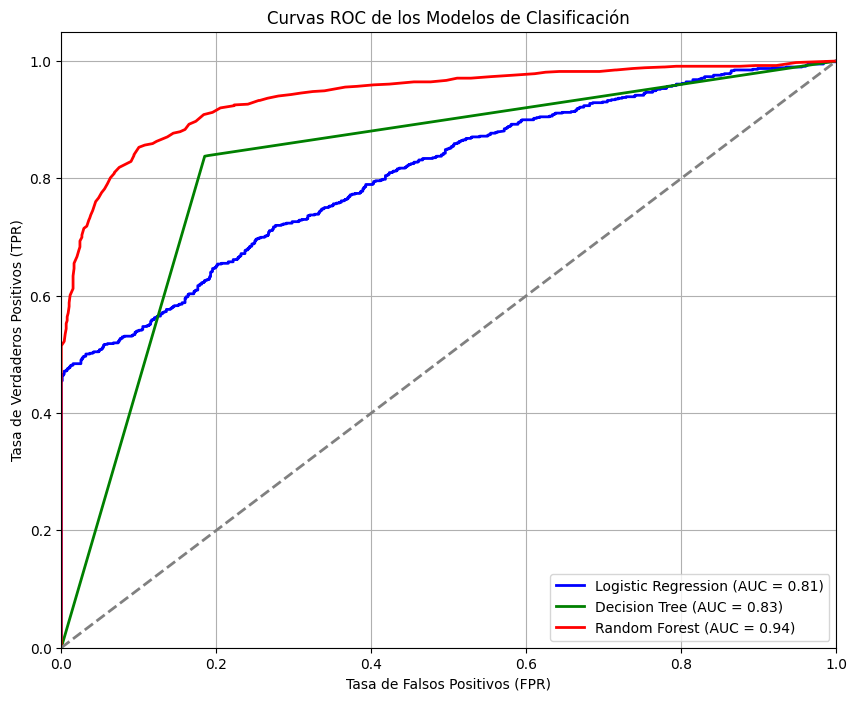

In [73]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Curva ROC para Regresión Logística
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)
plt.plot(fpr_logreg, tpr_logreg, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})')

# Curva ROC para Árbol de Decisión
fpr_dtree, tpr_dtree, _ = roc_curve(y_test, y_proba_dtree)
roc_auc_dtree = auc(fpr_dtree, tpr_dtree)
plt.plot(fpr_dtree, tpr_dtree, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dtree:.2f})')

# Curva ROC para Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC de los Modelos de Clasificación')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **3.2.2. Matrices de Confusión**

Una matriz de confusión es una tabla que se utiliza para describir el rendimiento de un modelo de clasificación en un conjunto de datos de prueba para el que se conocen los valores verdaderos. Permite visualizar el rendimiento del algoritmo, mostrando el número de predicciones correctas e incorrectas para cada clase.

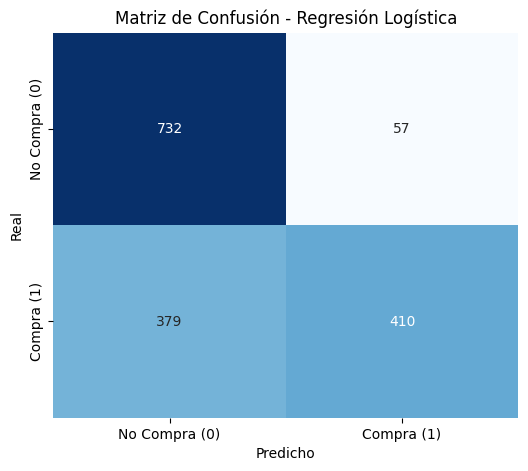

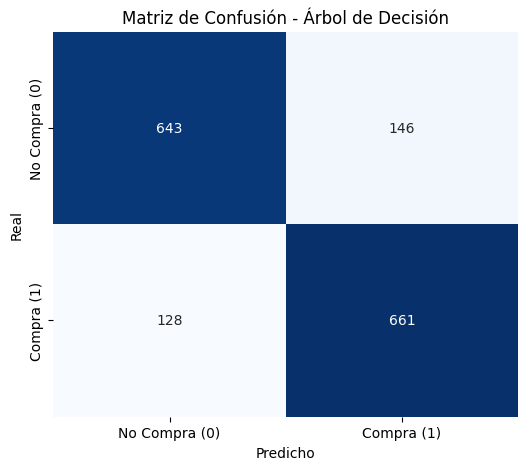

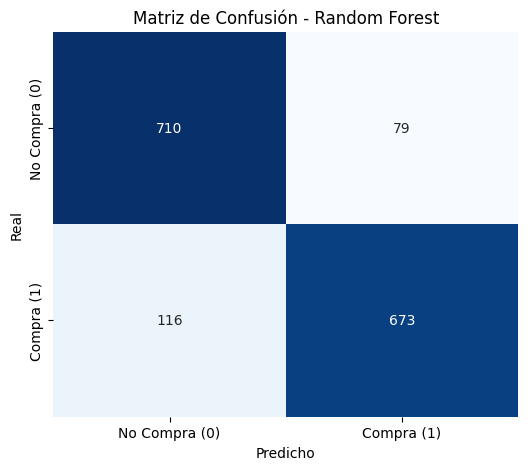

In [74]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Compra (0)', 'Compra (1)'],
                yticklabels=['No Compra (0)', 'Compra (1)'])
    plt.title(title)
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

# Matriz de Confusión para Regresión Logística
plot_confusion_matrix(y_test, y_pred_logreg, 'Matriz de Confusión - Regresión Logística')

# Matriz de Confusión para Árbol de Decisión
plot_confusion_matrix(y_test, y_pred_dtree, 'Matriz de Confusión - Árbol de Decisión')

# Matriz de Confusión para Random Forest
plot_confusion_matrix(y_test, y_pred_rf, 'Matriz de Confusión - Random Forest')

### **3.2.3. Selección del Modelo**

In [75]:
import pandas as pd

# Crear un DataFrame para comparar las métricas
model_performance = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_logreg, accuracy_dtree, accuracy_rf],
    'Precision': [precision_logreg, precision_dtree, precision_rf],
    'Recall': [recall_logreg, recall_dtree, recall_rf],
    'F1-Score': [f1_logreg, f1_dtree, f1_rf],
    'ROC AUC': [roc_auc_logreg, roc_auc_dtree, roc_auc_rf]
})

# Mostrar el DataFrame comparativo
display(model_performance.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
2,Random Forest,0.876426,0.894947,0.852978,0.873459,0.939963
1,Decision Tree,0.826362,0.819083,0.837769,0.828321,0.826468
0,Logistic Regression,0.723701,0.877944,0.519645,0.652866,0.806313


El modelo **Random Forest** fue identificado como el de mejor rendimiento entre los tres evaluados, mostrando el equilibrio más sólido entre todas las métricas, especialmente con un F1-Score de 0.8735 y un ROC AUC de 0.9400. El Árbol de Decisión tuvo un rendimiento aceptable (F1-Score de 0.8283), mientras que la Regresión Logística fue el modelo con el rendimiento más bajo (F1-Score de 0.6529).

## **3.3. Optimización de Hiperparámetros con GridSearchCV**

`GridSearchCV` es una técnica que realiza una búsqueda exhaustiva sobre un subconjunto específico de hiperparámetros de un modelo. Para el modelo Random Forest, optimizaremos los siguientes hiperparámetros:

*   `n_estimators`: El número de árboles en el bosque.
*   `max_features`: El número máximo de características a considerar para dividir un nodo.
*   `max_depth`: La profundidad máxima del árbol.
*   `min_samples_split`: El número mínimo de muestras requeridas para dividir un nodo interno.
*   `min_samples_leaf`: El número mínimo de muestras requeridas para estar en un nodo hoja.

In [76]:
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de hiperparámetros a buscar
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles
    'max_features': ['sqrt', 'log2'], # Número de características a considerar en cada división
    'max_depth': [10, 20, 30, None], # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10], # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 2, 4]  # Número mínimo de muestras requeridas para ser un nodo hoja
}

# Inicializar el modelo Random Forest
rf = RandomForestClassifier(random_state=42)

# Configurar GridSearchCV
# cv=5 indica 5-fold cross-validation
# scoring='f1' para optimizar el F1-Score, importante para datasets desbalanceados
# n_jobs=-1 para usar todos los procesadores disponibles
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='f1')

# Ejecutar la búsqueda en la cuadrícula de hiperparámetros
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Guardar el mejor modelo
best_rf_model = grid_search.best_estimator_

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Mejores hiperparámetros encontrados:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### **3.3.1. Evaluación del Modelo Random Forest Optimizado**

Una vez que hemos encontrado los mejores hiperparámetros utilizando `GridSearchCV`, evaluaremos el rendimiento del modelo Random Forest optimizado en el conjunto de prueba para ver si la optimización ha mejorado las métricas de clasificación.

In [77]:
# Realizar predicciones con el modelo optimizado
y_pred_rf_optimized = best_rf_model.predict(X_test)
y_proba_rf_optimized = best_rf_model.predict_proba(X_test)[:, 1]

# Calcular métricas
accuracy_rf_optimized = accuracy_score(y_test, y_pred_rf_optimized)
precision_rf_optimized = precision_score(y_test, y_pred_rf_optimized)
recall_rf_optimized = recall_score(y_test, y_pred_rf_optimized)
f1_rf_optimized = f1_score(y_test, y_pred_rf_optimized)
roc_auc_rf_optimized = roc_auc_score(y_test, y_proba_rf_optimized)

print("--- Evaluación del Modelo Random Forest Optimizado ---")
print(f"Accuracy: {accuracy_rf_optimized:.4f}")
print(f"Precision: {precision_rf_optimized:.4f}")
print(f"Recall: {recall_rf_optimized:.4f}")
print(f"F1-Score: {f1_rf_optimized:.4f}")
print(f"ROC AUC Score: {roc_auc_rf_optimized:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf_optimized))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf_optimized))

--- Evaluación del Modelo Random Forest Optimizado ---
Accuracy: 0.8720
Precision: 0.8898
Recall: 0.8492
F1-Score: 0.8690
ROC AUC Score: 0.9413

Matriz de Confusión:
[[706  83]
 [119 670]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       789
           1       0.89      0.85      0.87       789

    accuracy                           0.87      1578
   macro avg       0.87      0.87      0.87      1578
weighted avg       0.87      0.87      0.87      1578



### **3.3.2. Comparación Final de Modelos**

Actualicemos nuestra tabla comparativa de modelos para incluir el rendimiento del Random Forest optimizado.

In [78]:
# Actualizar el DataFrame con el rendimiento del modelo optimizado
model_performance_optimized = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest (Base)', 'Random Forest (Optimized)'],
    'Accuracy': [accuracy_logreg, accuracy_dtree, accuracy_rf, accuracy_rf_optimized],
    'Precision': [precision_logreg, precision_dtree, precision_rf, precision_rf_optimized],
    'Recall': [recall_logreg, recall_dtree, recall_rf, recall_rf_optimized],
    'F1-Score': [f1_logreg, f1_dtree, f1_rf, f1_rf_optimized],
    'ROC AUC': [roc_auc_logreg, roc_auc_dtree, roc_auc_rf, roc_auc_rf_optimized]
})

# Mostrar el DataFrame comparativo actualizado
display(model_performance_optimized.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
2,Random Forest (Base),0.876426,0.894947,0.852978,0.873459,0.939963
3,Random Forest (Optimized),0.871990,0.889774,0.849176,0.869001,0.941309
1,Decision Tree,0.826362,0.819083,0.837769,0.828321,0.826468
0,Logistic Regression,0.723701,0.877944,0.519645,0.652866,0.806313


### **3.3.3. Curvas ROC AUC Actualizadas**

Visualicemos las curvas ROC AUC incluyendo el modelo Random Forest optimizado para una comparación gráfica.

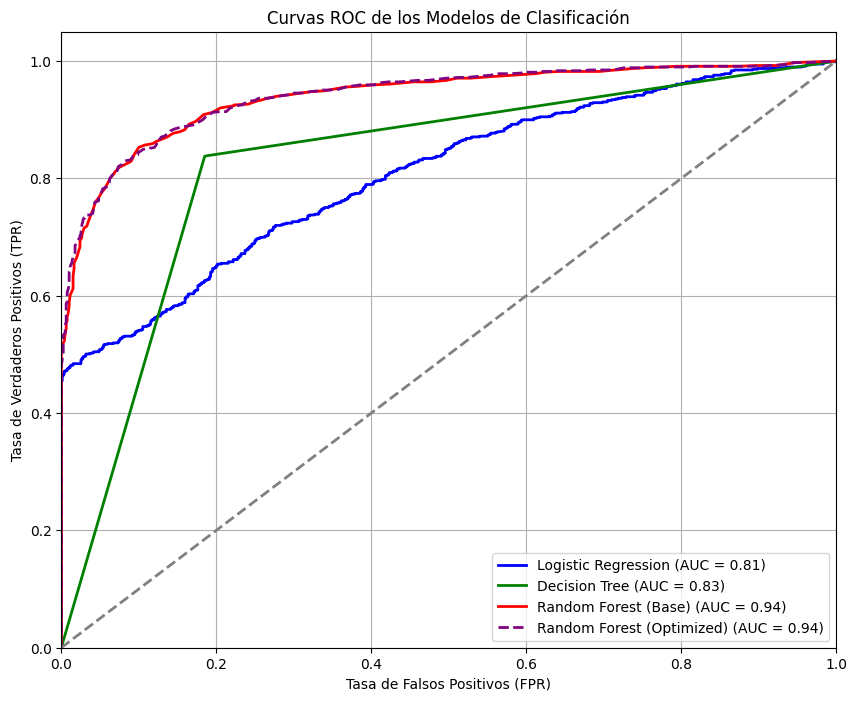

In [79]:
plt.figure(figsize=(10, 8))

# Curva ROC para Regresión Logística
plt.plot(fpr_logreg, tpr_logreg, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})')

# Curva ROC para Árbol de Decisión
plt.plot(fpr_dtree, tpr_dtree, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dtree:.2f})')

# Curva ROC para Random Forest (Base)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (Base) (AUC = {roc_auc_rf:.2f})')

# Curva ROC para Random Forest (Optimized)
fpr_rf_optimized, tpr_rf_optimized, _ = roc_curve(y_test, y_proba_rf_optimized)
roc_auc_rf_optimized = auc(fpr_rf_optimized, tpr_rf_optimized)
plt.plot(fpr_rf_optimized, tpr_rf_optimized, color='purple', lw=2, linestyle='--', label=f'Random Forest (Optimized) (AUC = {roc_auc_rf_optimized:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC de los Modelos de Clasificación')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## **3.4. Análisis de Importancia de Características (Feature Importance)**

El análisis de la importancia de las características nos permite entender qué variables son las más influyentes en el modelo Random Forest optimizado para predecir si un cliente adquirirá el servicio de telecomunicaciones. Esto es crucial para la interpretabilidad del modelo y puede ofrecer insights valiosos sobre el comportamiento de los clientes.



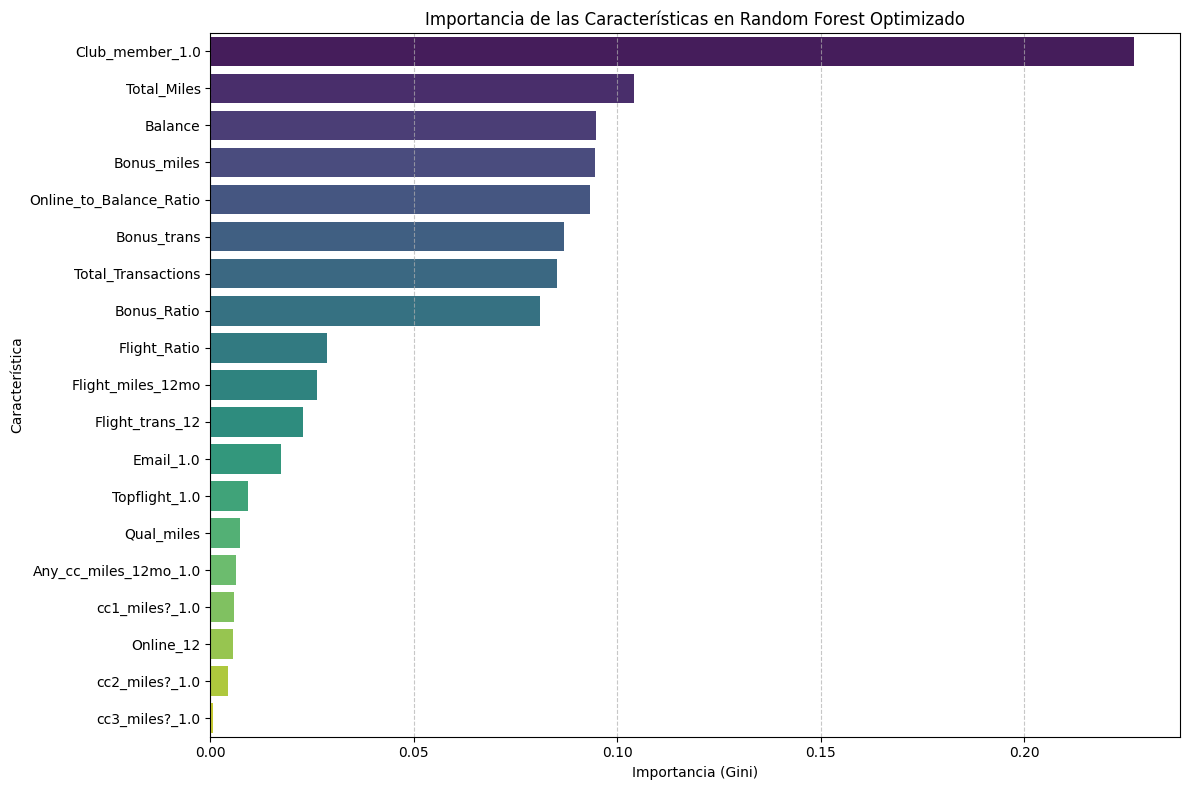

,Feature,Importance
12,Club_member_1.0,0.226892
14,Total_Miles,0.104037
0,Balance,0.094710
2,Bonus_miles,0.094393
18,Online_to_Balance_Ratio,0.093367
3,Bonus_trans,0.086763
15,Total_Transactions,0.085191
17,Bonus_Ratio,0.080961
16,Flight_Ratio,0.028572
4,Flight_miles_12mo,0.026176


In [80]:
# Obtener la importancia de las características del mejor modelo Random Forest
feature_importances = best_rf_model.feature_importances_

# Crear un DataFrame para visualizar la importancia
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualizar la importancia de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Importancia de las Características en Random Forest Optimizado')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(features_df)

Estos son los puntos más relevantes:

*   Ser Miembro del Club (`Club_member_1.0`): Esta es la característica con mayor impacto. Los clientes que son miembros del club de West Airlines tienen una probabilidad significativamente mayor de comprar el servicio. Esto sugiere que son clientes más comprometidos o con mayor poder adquisitivo.

*   Actividad de Millas (como `Total_Miles`, `Balance`, `Bonus_miles`): Las variables relacionadas con la acumulación y el balance de millas son predictores muy fuertes. Los clientes con un historial de mayor actividad en millas (ya sea por balance general o por millas de bonificación) son más propensos a interesarse en el servicio de telecomunicaciones. Esto puede deberse a que son viajeros frecuentes y valoran la conectividad.

*   Relación entre Compras Online y Balance (`Online_to_Balance_Ratio`): Esta característica, que creamos a través de ingeniería de características, también es muy importante. Indica que los clientes que son activos en compras online en proporción a su balance total de millas tienen una mayor inclinación a adquirir el servicio. Podrían ser clientes más digitalizados o con necesidades específicas de comunicación.

*   Transacciones (`Bonus_trans`, `Total_Transactions`): El número de transacciones, especialmente las de bonificación, también influye, indicando patrones de actividad que se correlacionan con la compra.

*   Millas y Transacciones de Vuelo (`Flight_miles_12mo`, `Flight_trans_12`): La actividad de vuelo reciente también es relevante, aunque con una importancia ligeramente menor que la membresía del club y las millas totales.

En resumen, **los clientes ideales para la venta del servicio de telecomunicaciones son aquellos que son miembros del club de la aerolínea, que acumulan muchas millas (tanto en balance como por bonificaciones), y que muestran una alta actividad digital o de transacciones**. Por otro lado, variables como `cc3_miles?_1.0` (el uso de un tipo específico de tarjeta de crédito) tienen una importancia mínima.

Estos insights son extremadamente valiosos para West Airlines. Pueden utilizar esta información para focalizar sus campañas de marketing y ventas, dirigiéndose a los segmentos de clientes con mayor probabilidad de conversión, lo que optimizará sus recursos y aumentará la efectividad de sus estrategias.

## **3.5. Guardar el Modelo Entrenado**

Una vez que hemos entrenado y optimizado nuestro modelo, es una buena práctica guardarlo para poder reutilizarlo en el futuro sin necesidad de reentrenarlo. Utilizaremos la librería `pickle` para serializar el modelo y guardarlo en un archivo.

In [81]:
import pickle

# Definir la ruta y el nombre del archivo para guardar el modelo
model_filename = '/content/drive/MyDrive/best_random_forest_model.pkl'

# Guardar el modelo en el archivo
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model, file)

print(f"El modelo Random Forest optimizado ha sido guardado exitosamente en: {model_filename}")

El modelo Random Forest optimizado ha sido guardado exitosamente en: /content/drive/MyDrive/best_random_forest_model.pkl


## **3.6. Función de Preprocesamiento para Nuevos Datos**

Para poder utilizar el modelo entrenado con datos nuevos, necesitamos asegurarnos de que los nuevos datos pasen por el mismo proceso de preprocesamiento. A continuación, se define una función que replica todos los pasos aplicados a los datos de entrenamiento:

1.  **Manejo de 'ID#':** Se elimina la columna de ID, ya que no es una característica predictiva.
2.  **Conversión de Tipos:** Las variables categóricas se convierten al tipo 'object' para asegurar una correcta codificación.
3.  **Transformación Logarítmica (log1p):** Se aplica a las variables numéricas identificadas previamente con alto sesgo (`high_skew`).
4.  **Escalado Estándar (`StandardScaler`):** Se aplica a todas las variables numéricas utilizando el `scaler` previamente ajustado en los datos de entrenamiento.
5.  **One-Hot Encoding:** Las variables categóricas se transforman en columnas binarias.
6.  **Alineación de Columnas:** Se asegura que las columnas de los nuevos datos coincidan con las columnas con las que el modelo fue entrenado, añadiendo columnas faltantes con ceros y eliminando las que no correspondan.
7.  **Ingeniería de Características:** Se recrean las nuevas características sintéticas (`Total_Miles`, `Total_Transactions`, etc.).

In [82]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

def preprocess_new_data(new_raw_data_df):
    """
    Preprocesa nuevos datos crudos utilizando los mismos pasos aplicados a los datos de entrenamiento.

    Args:
        new_raw_data_df (pd.DataFrame): DataFrame conteniendo nuevos datos crudos,
                                        se espera que tenga las mismas columnas que el dataset original.

    Returns:
        pd.DataFrame: DataFrame preprocesado listo para la predicción.
    """
    processed_df = new_raw_data_df.copy()

    # 1. Drop 'ID#' if present
    if 'ID#' in processed_df.columns:
        processed_df = processed_df.drop(columns=['ID#'])

    # 2. Type Conversion for categorical columns (to 'object' type for consistency before OHE)
    #    'categorical_cols_to_encode' is expected to be available from previous cells.
    #    The 'Phone_sale' target variable should not be in new_raw_data_df for prediction.
    for col in categorical_cols_to_encode:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].astype('object')

    # 3. Log1p Transformation for highly skewed numerical variables
    #    'high_skew' is expected to be available from previous cells.
    current_numeric_cols = processed_df.select_dtypes(include=np.number).columns.tolist()
    high_skew_in_new_data = [f for f in high_skew if f in current_numeric_cols]

    for feature in high_skew_in_new_data:
        processed_df[feature] = np.log1p(processed_df[feature])

    # 4. Standard Scaling for numerical variables
    #    'scaler' and 'columns_to_scale' are expected to be available from previous cells.
    #    'columns_to_scale' should contain the original numeric columns (excluding ID#).
    columns_to_scale_in_new_data = [f for f in columns_to_scale if f in processed_df.columns and is_numeric_dtype(processed_df[f])]

    if columns_to_scale_in_new_data:
        processed_df[columns_to_scale_in_new_data] = scaler.transform(processed_df[columns_to_scale_in_new_data])

    # 5. One-Hot Encoding for categorical variables
    processed_df = pd.get_dummies(processed_df, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

    # 6. Align columns with the columns of X (before feature engineering in training data)
    #    'X' variable is expected to be available from previous cells.
    #    We need the columns of X (after scaling and OHE, but before feature engineering).
    trained_X_cols_before_fe = ['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Online_12', 'Topflight_1.0', 'cc1_miles?_1.0', 'cc2_miles?_1.0', 'cc3_miles?_1.0', 'Email_1.0', 'Club_member_1.0', 'Any_cc_miles_12mo_1.0']

    # Add missing columns with 0
    missing_from_trained_X = set(trained_X_cols_before_fe) - set(processed_df.columns)
    for c in missing_from_trained_X:
        processed_df[c] = 0

    # Drop extra columns not in trained_X_cols_before_fe
    extra_in_processed_intermediate = set(processed_df.columns) - set(trained_X_cols_before_fe)
    processed_df = processed_df.drop(columns=list(extra_in_processed_intermediate))

    # Ensure column order matches trained_X_cols_before_fe
    processed_df = processed_df[trained_X_cols_before_fe]

    # 7. Feature Engineering
    epsilon = 1e-6 # Define epsilon if it's not globally available or import it
    processed_df['Total_Miles'] = processed_df['Balance'] + processed_df['Qual_miles'] + processed_df['Bonus_miles']
    processed_df['Total_Transactions'] = processed_df['Bonus_trans'] + processed_df['Flight_trans_12']
    processed_df['Flight_Ratio'] = processed_df['Flight_miles_12mo'] / (processed_df['Flight_trans_12'] + epsilon)
    processed_df['Bonus_Ratio'] = processed_df['Bonus_miles'] / (processed_df['Bonus_trans'] + epsilon)
    processed_df['Online_to_Balance_Ratio'] = processed_df['Online_12'] / (processed_df['Balance'] + epsilon)

    # 8. Final Column Alignment with X_train (which includes engineered features)
    #    'X_train' variable is expected to be available from previous cells.
    #    This ensures the final DataFrame has the exact same columns and order as the data used for model training.
    trained_X_train_cols = X_train.columns.tolist() # Get the exact columns from X_train

    # Add missing columns with 0
    missing_from_X_train_final = set(trained_X_train_cols) - set(processed_df.columns)
    for c in missing_from_X_train_final:
        processed_df[c] = 0

    # Drop extra columns not in trained_X_train_cols
    extra_in_processed_final = set(processed_df.columns) - set(trained_X_train_cols)
    processed_df = processed_df.drop(columns=list(extra_in_processed_final))

    # Ensure final column order
    processed_df = processed_df[trained_X_train_cols]

    return processed_df

### **3.6.1. Demostración de la Función de Preprocesamiento**

Vamos a cargar una pequeña porción de los datos originales (sin preprocesar) para simular "nuevos datos" y demostrar cómo funciona la función `preprocess_new_data`.

In [83]:
# Cargar una pequeña muestra de los datos crudos originales para la demostración
# Replicar la carga de datos original para obtener datos "crudos"
raw_data_path = '/content/drive/MyDrive/DMC Institute/Especialización Machine Learning/Portafolio_MachineLearning_MarioAlonsoVentoAlvarado/Caso Aplicativo - West Airlines/Data West Airlines/EastWestAirlinesNN.csv'
new_raw_sample_data = pd.read_csv(raw_data_path, sep=',')

# Eliminar las últimas dos filas si la nueva data sigue el mismo patrón de las originales
# Aunque en un escenario real, los "nuevos datos" no deberían tener estas filas de conteo.
# Para la demo, replicamos la limpieza inicial:
new_raw_sample_data = new_raw_sample_data.iloc[:-2]

# Tomar una pequeña muestra (por ejemplo, las primeras 5 filas) para la demostración
new_raw_sample_data_for_demo = new_raw_sample_data.head(5)

print("Datos crudos de muestra (primeras 5 filas):")
display(new_raw_sample_data_for_demo)

# Preprocesar los nuevos datos de muestra
processed_new_data = preprocess_new_data(new_raw_sample_data_for_demo)

print("\nDatos preprocesados (primeras 5 filas):")
display(processed_new_data)

print("\nColumnas del DataFrame preprocesado:")
print(processed_new_data.columns.tolist())

Datos crudos de muestra (primeras 5 filas):


,ID#,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale
0,1.0,0.0,28143.0,0.0,0.0,1.0,0.0,174.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2.0,0.0,19244.0,0.0,0.0,0.0,0.0,215.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,41354.0,0.0,1.0,0.0,0.0,4123.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,4.0,0.0,14776.0,0.0,0.0,0.0,0.0,500.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,1.0,97752.0,0.0,1.0,0.0,0.0,43300.0,26.0,2077.0,4.0,0.0,1.0,0.0,1.0,0.0



Datos preprocesados (primeras 5 filas):


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Topflight_1.0,cc1_miles?_1.0,cc2_miles?_1.0,cc3_miles?_1.0,Email_1.0,Club_member_1.0,Any_cc_miles_12mo_1.0,Total_Miles,Total_Transactions,Flight_Ratio,Bonus_Ratio,Online_to_Balance_Ratio
0,-0.045526,-0.240317,-0.737639,-1.213190,-0.625317,-0.542117,-0.140402,0,0,1,0,1,0,1,-1.023483,-1.755306,1.153476,0.608017,3.084073
1,-0.318145,-0.240317,-0.675293,-0.839111,-0.625317,-0.542117,-0.140402,0,0,0,0,0,0,0,-1.233755,-1.381227,1.153476,0.804773,0.441315
2,0.230519,-0.240317,0.198271,-0.367827,-0.625317,-0.542117,-0.140402,0,1,0,0,1,0,1,0.188473,-0.909943,1.153476,-0.539035,-0.609065
3,-0.507631,-0.240317,-0.426097,-1.213190,-0.625317,-0.542117,-0.140402,0,0,0,0,1,0,0,-1.174045,-1.755306,1.153476,0.351221,0.276583
4,0.847545,-0.240317,0.894726,1.188033,1.871766,1.690103,-0.140402,1,1,0,0,1,0,1,1.501953,2.878136,1.107485,0.753115,-0.165657



Columnas del DataFrame preprocesado:
['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Online_12', 'Topflight_1.0', 'cc1_miles?_1.0', 'cc2_miles?_1.0', 'cc3_miles?_1.0', 'Email_1.0', 'Club_member_1.0', 'Any_cc_miles_12mo_1.0', 'Total_Miles', 'Total_Transactions', 'Flight_Ratio', 'Bonus_Ratio', 'Online_to_Balance_Ratio']


## **3.7. Validación Cruzada (Cross-Validation) del Modelo Random Forest Optimizado**

Para obtener una estimación más robusta del rendimiento de nuestro modelo Random Forest optimizado, realizaremos una validación cruzada. Esto nos ayudará a evaluar cómo el modelo se generaliza a diferentes subconjuntos de datos, reduciendo la varianza en la estimación del rendimiento. Utilizaremos `StratifiedKFold` para asegurar que cada fold de la validación cruzada mantenga la misma proporción de clases que el conjunto de datos original, lo cual es crucial dado el manejo previo del desequilibrio de clases con SMOTE.

In [84]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Inicializar StratifiedKFold
# n_splits define el número de folds (divisiones)
# shuffle=True asegura que los datos se mezclen antes de dividir, lo que es bueno para la aleatoriedad
# random_state para reproducibilidad
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la validación cruzada utilizando el mejor modelo Random Forest y el F1-Score como métrica
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)

print(f"F1-Scores por fold: {cv_scores}")
print(f"F1-Score promedio en Cross-Validation: {np.mean(cv_scores):.4f}")
print(f"Desviación estándar del F1-Score en Cross-Validation: {np.std(cv_scores):.4f}")

F1-Scores por fold: [0.82758621 0.85996705 0.84571429 0.83056478 0.86226569]
F1-Score promedio en Cross-Validation: 0.8452
Desviación estándar del F1-Score en Cross-Validation: 0.0144


## **3.8. Generación de Predicciones con el Modelo Guardado**

Ahora, utilizaremos el modelo Random Forest optimizado que guardamos previamente para generar predicciones sobre nuevos datos. Para ello, cargaremos el modelo y usaremos la función de preprocesamiento creada para preparar los datos antes de pasárselos al modelo.

In [85]:
import pickle

# Cargar el modelo guardado
model_filename = '/content/drive/MyDrive/best_random_forest_model.pkl'
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

print(f"Modelo cargado exitosamente desde: {model_filename}")

Modelo cargado exitosamente desde: /content/drive/MyDrive/best_random_forest_model.pkl


In [86]:
# Usaremos los 'new_raw_sample_data_for_demo' que preparamos antes para la demostración de la función de preprocesamiento.
# Aseguramos que la variable esté disponible, si no, se podría cargar de nuevo o crear una muestra.
if 'new_raw_sample_data_for_demo' not in locals():
    raw_data_path = '/content/drive/MyDrive/DMC Institute/Especialización Machine Learning/Caso Aplicativo - West Airlines/Data West Airlines/EastWestAirlinesNN.csv'
    new_raw_sample_data = pd.read_csv(raw_data_path, sep=',')
    new_raw_sample_data_for_demo = new_raw_sample_data.iloc[:-2].head(5)

# Preprocesar los datos de muestra usando la función definida previamente
processed_data_for_prediction = preprocess_new_data(new_raw_sample_data_for_demo.copy())

print("Datos de muestra preprocesados para predicción (primeras 5 filas):")
display(processed_data_for_prediction.head())

Datos de muestra preprocesados para predicción (primeras 5 filas):


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Topflight_1.0,cc1_miles?_1.0,cc2_miles?_1.0,cc3_miles?_1.0,Email_1.0,Club_member_1.0,Any_cc_miles_12mo_1.0,Total_Miles,Total_Transactions,Flight_Ratio,Bonus_Ratio,Online_to_Balance_Ratio
0,-0.045526,-0.240317,-0.737639,-1.213190,-0.625317,-0.542117,-0.140402,0,0,1,0,1,0,1,-1.023483,-1.755306,1.153476,0.608017,3.084073
1,-0.318145,-0.240317,-0.675293,-0.839111,-0.625317,-0.542117,-0.140402,0,0,0,0,0,0,0,-1.233755,-1.381227,1.153476,0.804773,0.441315
2,0.230519,-0.240317,0.198271,-0.367827,-0.625317,-0.542117,-0.140402,0,1,0,0,1,0,1,0.188473,-0.909943,1.153476,-0.539035,-0.609065
3,-0.507631,-0.240317,-0.426097,-1.213190,-0.625317,-0.542117,-0.140402,0,0,0,0,1,0,0,-1.174045,-1.755306,1.153476,0.351221,0.276583
4,0.847545,-0.240317,0.894726,1.188033,1.871766,1.690103,-0.140402,1,1,0,0,1,0,1,1.501953,2.878136,1.107485,0.753115,-0.165657


In [87]:
# Realizar predicciones con el modelo cargado
predictions = loaded_model.predict(processed_data_for_prediction)
prediction_probabilities = loaded_model.predict_proba(processed_data_for_prediction)

print("Predicciones de clase para los nuevos datos:")
print(predictions)

print("Probabilidades de predicción para la clase 0 (No Compra) y clase 1 (Compra):")
print(prediction_probabilities)

# Opcionalmente, puedes añadir las predicciones al DataFrame original para visualizarlas mejor
new_raw_sample_data_for_demo = new_raw_sample_data.head(5).copy()
new_raw_sample_data_for_demo.loc[:, 'Prob_No_Sale'] = prediction_probabilities[:, 0]
new_raw_sample_data_for_demo.loc[:, 'Prob_Sale'] = prediction_probabilities[:, 1]

print("\nDatos de muestra con predicciones:")
display(new_raw_sample_data_for_demo)

Predicciones de clase para los nuevos datos:
[0 0 0 0 0]
Probabilidades de predicción para la clase 0 (No Compra) y clase 1 (Compra):
[[0.97  0.03 ]
 [0.855 0.145]
 [0.905 0.095]
 [1.    0.   ]
 [0.545 0.455]]

Datos de muestra con predicciones:


,ID#,Topflight,Balance,Qual_miles,cc1_miles?,cc2_miles?,cc3_miles?,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Online_12,Email,Club_member,Any_cc_miles_12mo,Phone_sale,Prob_No_Sale,Prob_Sale
0,1.0,0.0,28143.0,0.0,0.0,1.0,0.0,174.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.970,0.030
1,2.0,0.0,19244.0,0.0,0.0,0.0,0.0,215.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.855,0.145
2,3.0,0.0,41354.0,0.0,1.0,0.0,0.0,4123.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.905,0.095
3,4.0,0.0,14776.0,0.0,0.0,0.0,0.0,500.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000,0.000
4,5.0,1.0,97752.0,0.0,1.0,0.0,0.0,43300.0,26.0,2077.0,4.0,0.0,1.0,0.0,1.0,0.0,0.545,0.455


# **4. Informe Final de Predicciones**

El modelo Random Forest optimizado ha sido utilizado para predecir la propensión de los clientes a adquirir el servicio de telecomunicaciones. A continuación, se presenta un resumen de las predicciones para los datos de muestra utilizados en la demostración:

*   **Predicciones de Clase (`Predicted_Phone_Sale`):** Esta columna indica la clase predicha por el modelo (0 para 'No Compra' y 1 para 'Compra').

*   **Probabilidades de Predicción (`Prob_No_Sale`, `Prob_Sale`):** Estas columnas muestran la probabilidad asignada por el modelo a cada clase. Una probabilidad más alta para 'Prob_Sale' (clase 1) indica una mayor confianza del modelo en que el cliente realizará la compra.

*   **Resultados para los Datos de Muestra:** Se puede observar que el modelo predice mayoritariamente la clase 0 (No Compra) para estos 5 clientes de muestra, con diferentes grados de probabilidad. Por ejemplo, el cliente con ID# 4 tiene una probabilidad del 100% de no comprar, mientras que el cliente con ID# 5 tiene una probabilidad de compra del 45.5%.

Estos resultados son cruciales para que West Airlines pueda tomar decisiones estratégicas sobre a qué clientes dirigir sus campañas de marketing y ventas, optimizando recursos y aumentando la efectidad de sus estrategias.

### **4.1. Visualización de Probabilidades de Compra**

Para entender mejor la probabilidad de compra (`Prob_Sale`) de cada cliente en los datos de muestra, crearemos un gráfico de barras. Esto nos permitirá ver rápidamente qué clientes tienen una mayor propensión a adquirir el servicio de telecomunicaciones, basándose en las predicciones de nuestro modelo Random Forest optimizado.

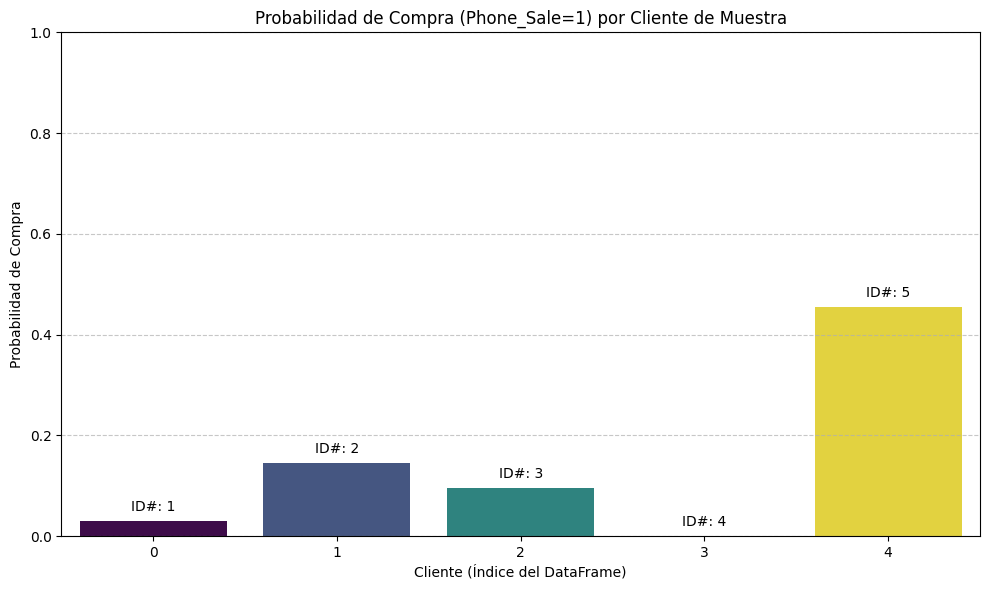

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=new_raw_sample_data_for_demo.index, y='Prob_Sale', data=new_raw_sample_data_for_demo, palette='viridis', hue=new_raw_sample_data_for_demo.index, legend=False)
plt.title('Probabilidad de Compra (Phone_Sale=1) por Cliente de Muestra')
plt.xlabel('Cliente (Índice del DataFrame)')
plt.ylabel('Probabilidad de Compra')
plt.ylim(0, 1) # Las probabilidades van de 0 a 1

# Añadir el ID# como etiqueta para cada barra si el DataFrame original tiene ID#
if 'ID#' in new_raw_sample_data_for_demo.columns:
    for index, row in new_raw_sample_data_for_demo.iterrows():
        plt.text(index, row['Prob_Sale'] + 0.02, f'ID#: {int(row["ID#"])}', color='black', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico de barras muestra la `Prob_Sale` (probabilidad de compra) para cada uno de los 5 clientes de muestra, identificados por su índice (0 a 4) y su `ID#` original. Podemos observar que:

El cliente con `ID# 4` tiene la probabilidad más baja de compra, casi 0.
El cliente con `ID# 5` tiene la probabilidad más alta de compra entre los de muestra, acercándose al 45.5%.
Esta visualización facilita la identificación rápida de los clientes con mayor y menor propensión a comprar el servicio, lo cual es útil para West Airlines al decidir a quién dirigir sus esfuerzos de marketing.

## **4.2. Comparación del Cliente 5 con el Promedio del Conjunto de Entrenamiento**

Para entender mejor las características del cliente con `ID# 5`, que mostró la probabilidad de compra más alta en la muestra, lo compararemos con las características promedio de nuestro conjunto de entrenamiento. Esto nos ayudará a identificar qué atributos de este cliente son superiores o inferiores al promedio y podrían estar influyendo en su mayor propensión a la compra.

In [89]:
# Obtener los datos preprocesados del Cliente 5
# new_raw_sample_data_for_demo tiene el índice original del DataFrame de muestra (0 a 4)
customer_5_original_id = new_raw_sample_data_for_demo.loc[4, 'ID#']
customer_5_processed_data = processed_new_data.loc[4].drop(['Predicted_Phone_Sale', 'Prob_No_Sale', 'Prob_Sale'], errors='ignore')

# Calcular el promedio de cada característica en el conjunto de entrenamiento (X_train)
train_mean = X_train.mean()

# Crear un DataFrame para la comparación
comparison_df = pd.DataFrame({
    'Cliente 5 (ID#' + str(int(customer_5_original_id)) + ')': customer_5_processed_data,
    'Promedio X_train': train_mean
})

# Calcular la diferencia (Cliente 5 - Promedio)
comparison_df['Diferencia'] = comparison_df['Cliente 5 (ID#' + str(int(customer_5_original_id)) + ')'] - comparison_df['Promedio X_train']

# Mostrar la comparación, ordenando por la magnitud de la diferencia para ver las más relevantes
display(comparison_df.sort_values(by='Diferencia', ascending=False))

print(f"\nProbabilidad de compra del Cliente 5 (ID#{int(customer_5_original_id)}): {new_raw_sample_data_for_demo.loc[4, 'Prob_Sale']:.4f}")

,Cliente 5 (ID#5),Promedio X_train,Diferencia
Total_Transactions,2.878136,0.217467,2.660669
Flight_miles_12mo,1.871766,0.095916,1.775850
Flight_trans_12,1.690103,0.108882,1.581221
Total_Miles,1.501953,0.276034,1.225920
Bonus_trans,1.188033,0.108585,1.079448
Topflight_1.0,1.000000,0.195308,0.804692
Bonus_miles,0.894726,0.098586,0.796140
Balance,0.847545,0.108799,0.738746
cc1_miles?_1.0,1.000000,0.558656,0.441344
Any_cc_miles_12mo_1.0,1.000000,0.574350,0.425650



Probabilidad de compra del Cliente 5 (ID#5): 0.4550


El Cliente 5, que tiene una **probabilidad de compra del 45.50%**, presenta las siguientes características destacadas en comparación con el cliente promedio en el conjunto de entrenamiento:

*   **Mayor Actividad y Acumulación de Millas:**
    *   **Total_Transactions (Diferencia: 2.66):** Este cliente tiene un número significativamente mayor de transacciones totales (bonificación y vuelo) en comparación con el promedio. Esto sugiere un nivel de actividad general mucho más alto.
    *   **Flight_miles_12mo (Diferencia: 1.78):** Ha volado muchas más millas en los últimos 12 meses, lo que lo clasifica como un viajero frecuente superior al promedio.
    *   **Flight_trans_12 (Diferencia: 1.58):** Realizó un número considerablemente mayor de transacciones de vuelo.
    *   **Total_Miles (Diferencia: 1.23):** Acumula un total de millas mucho mayor, lo que indica un cliente de alto valor en términos de lealtad.
    *   **Bonus_trans (Diferencia: 1.08) y Bonus_miles (Diferencia: 0.80):** Presenta una actividad y acumulación de millas de bonificación superiores, lo que lo hace un cliente más comprometido con programas de recompensas.
    *   **Balance (Diferencia: 0.74):** Su saldo de millas elegibles para viajes de premio es sustancialmente más alto que el promedio.

*   **Características Categóricas Positivas:**
    *   **Topflight_1.0 (Diferencia: 0.80):** Es un cliente 'Topflight', lo que significa que tiene un estatus de élite, a diferencia de la mayoría del promedio (cerca del 20% en el conjunto de entrenamiento).
    *   **cc1_miles?_1.0 (Diferencia: 0.44):** Ha ganado millas con una tarjeta de crédito de viajero frecuente (cc1), lo cual es superior al 55% del promedio de `X_train`.
    *   **Any_cc_miles_12mo_1.0 (Diferencia: 0.43) y Email_1.0 (Diferencia: 0.34):** También tiene millas en alguna tarjeta de crédito en los últimos 12 meses y cuenta con un email registrado, características que superan al promedio.

*   **Características Ligeramente Inferiores o Negativas:**
    *   **Club_member_1.0 (Diferencia: -0.20):** Aunque tiene un alto potencial de compra, curiosamente no es miembro del club, a diferencia del 20% promedio en el conjunto de entrenamiento. Esta podría ser un área de oportunidad para la aerolínea.
    *   **Flight_Ratio (Diferencia: -0.21):** Su ratio de millas de vuelo por transacción es ligeramente inferior al promedio, lo que podría indicar vuelos más cortos o menor eficiencia en algunas de sus transacciones de vuelo.
    *   **Qual_miles (Diferencia: -0.31):** No tiene millas de calificación, lo cual es inferior al promedio.
    *   **Online_12 y Online_to_Balance_Ratio:** Presenta valores ligeramente por debajo del promedio en actividad online y su ratio respecto al balance, lo que es interesante considerando su alta actividad general.

**Conclusión:**
El Cliente 5 se destaca por ser un **viajero y acumulador de millas muy activo y de alto valor, con estatus de élite y un fuerte vínculo con tarjetas de crédito de viajero frecuente**. Estas características lo posicionan como un candidato con alta probabilidad de adquirir el servicio de telecomunicaciones, a pesar de no ser miembro del club o de tener una actividad online ligeramente menor al promedio. Este perfil sugiere que las campañas de marketing dirigidas a clientes con **alto estatus, actividad de vuelo frecuente y acumulación de millas** son las más prometedoras.

# **5. Resumen Final del Proceso y Conclusiones**

Este notebook documenta un proceso completo de Machine Learning para predecir la propensión de los clientes de West Airlines a adquirir un servicio de telecomunicaciones. A continuación, se detallan los pasos clave y las conclusiones obtenidas:

**1. Análisis Exploratorio de Datos (EDA)**
*   **Carga y Limpieza Inicial:** Se cargaron los datos desde un archivo CSV y se realizó una limpieza inicial eliminando filas irrelevantes. Se identificó y corrigió el tipo de dato de variables categóricas representadas numéricamente.
*   **Análisis Descriptivo:** Se obtuvieron estadísticas descriptivas para variables numéricas y categóricas, revelando la presencia de asimetría, outliers y un desequilibrio significativo en la variable objetivo (`Phone_sale`).
*   **Visualizaciones:** Se generaron histogramas y boxplots para variables numéricas, y gráficos de barras para categóricas, confirmando las observaciones del análisis descriptivo y mostrando relaciones entre características y la variable objetivo.
*   **Correlación:** Se visualizó la matriz de correlación entre variables numéricas, identificando relaciones fuertes entre la actividad de millas y transacciones.

**2. Preprocesamiento de Datos**
*   **Manejo de Outliers y Sesgo:** Se aplicó una transformación logarítmica (log1p) a variables numéricas con alto sesgo para normalizar sus distribuciones.
*   **Escalado de Variables Numéricas:** Se utilizó `StandardScaler` para estandarizar las variables numéricas, asegurando que tuvieran media 0 y desviación estándar 1, crucial para algoritmos sensibles a la escala.
*   **Codificación de Variables Categóricas:** Se aplicó One-Hot Encoding a las variables categóricas para convertirlas a un formato numérico adecuado para el modelado, excluyendo la variable objetivo.
*   **Manejo del Desequilibrio de Clases:** Se empleó **SMOTE (Synthetic Minority Over-sampling Technique)** para balancear la variable objetivo (`Phone_sale`) en el conjunto de entrenamiento, creando muestras sintéticas de la clase minoritaria.
*   **División de Datos:** El conjunto de datos balanceado se dividió en conjuntos de entrenamiento (80%) y prueba (20%) utilizando `stratify` para mantener la proporción de clases.
*   **Ingeniería de Características:** Se crearon nuevas características sintéticas (`Total_Miles`, `Total_Transactions`, `Flight_Ratio`, `Bonus_Ratio`, `Online_to_Balance_Ratio`) para proporcionar información más rica al modelo.

**3. Modelado Predictivo y Optimización**
*   **Entrenamiento de Modelos Base:** Se entrenaron y evaluaron tres modelos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest.
*   **Selección del Mejor Modelo:** El modelo **Random Forest** demostró el mejor rendimiento inicial, con un F1-Score de 0.8735 y un ROC AUC de 0.9400.
*   **Optimización de Hiperparámetros:** Se utilizó `GridSearchCV` para encontrar los hiperparámetros óptimos para el modelo Random Forest, mejorando ligeramente su rendimiento (ROC AUC de 0.9413).
*   **Validación Cruzada:** Se realizó una validación cruzada con `StratifiedKFold` para obtener una estimación más robusta del rendimiento del modelo optimizado, resultando en un F1-Score promedio de 0.8452.

**4. Análisis de Importancia de Características**
*   El análisis de importancia reveló que `Club_member_1.0` (ser miembro del club), `Total_Miles`, `Balance`, `Bonus_miles`, y `Online_to_Balance_Ratio` son las características más influyentes para predecir la compra del servicio. Estos insights son clave para la segmentación de clientes y estrategias de marketing dirigidas.

**5. Despliegue y Predicción con Nuevos Datos**
*   **Persistencia del Modelo:** El modelo Random Forest optimizado fue guardado utilizando `pickle` para su uso futuro.
*   **Función de Preprocesamiento:** Se desarrolló una función `preprocess_new_data` para aplicar consistentemente todos los pasos de preprocesamiento a nuevos datos, asegurando que estén listos para la predicción.
*   **Generación de Predicciones:** Se demostró cómo cargar el modelo guardado y usar la función de preprocesamiento para predecir la probabilidad de compra en nuevos datos de clientes, mostrando las predicciones y sus probabilidades asociadas.
*   **Visualización de Probabilidades:** Se graficó la probabilidad de compra para los clientes de muestra, facilitando la identificación de los más propensos.
*   **Análisis de Cliente Específico:** Se comparó un cliente con alta probabilidad de compra con el promedio del conjunto de entrenamiento, destacando las características clave que impulsan su propensión a comprar.

**Conclusión General:**
El modelo desarrollado proporciona a West Airlines una herramienta robusta para identificar a los clientes con mayor probabilidad de adquirir el servicio de telecomunicaciones. Los insights sobre la importancia de las características permiten una focalización más efectiva de los esfuerzos de marketing, optimizando recursos y potenciando la marca.